# Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection of Steam Games

**Assignment:** Final Homework – Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Student Name:** Yuval Kravchik

**Student ID:** 206376071

**Instructor:** Dr. Uri Itai

**Teaching Assistant:** Hanit Hadad Ohayon

**Submission Deadline:** September 18, 2026

## Project Overview

This notebook presents an unsupervised learning analysis of a real-world Steam games dataset obtained from Kaggle, with the Steam-related data originating from SteamSpy.

The objective of the analysis is to investigate hidden structure, relationships, clusters, dimensionality, and anomalous observations within the dataset without relying on predefined labels.

The analysis combines exploratory data analysis, dimensionality reduction using Principal Component Analysis (PCA), multiple clustering techniques, and multi-dimensional anomaly detection methods.

Particular emphasis is placed not only on the numerical results produced by the algorithms, but also on understanding their assumptions, differences, limitations, and practical interpretation in the context of Steam games.

The analysis also examines whether unusual observations represent genuine anomalies, legitimate but rare games, data quality issues, or consequences of the assumptions made by the different methods.

## Notebook Structure

The notebook is organized into the following main sections:

1. Environment Setup and Data Loading

2. Dataset Selection and Source Description

3. Exploratory Data Analysis

   * Dataset Structure
   * Missing Values and Data Types
   * Statistical Summary
   * Feature Distributions
   * Skewness and Kurtosis
   * Correlation Analysis
   * Outlier Exploration

4. Dimensionality Reduction

   * Data Preprocessing and Scaling
   * Principal Component Analysis (PCA)
   * Explained and Cumulative Variance
   * Scree Plot
   * 2D and 3D PCA Projections
   * Principal Component Interpretation

5. Clustering Analysis

   * K-Means
   * DBSCAN
   * Hierarchical Clustering
   * Clustering Evaluation
   * Clustering in PCA Space
   * Feature-Space Clustering

6. Multi-Dimensional Anomaly Detection

   * Z-Score Method
   * Isolation Forest
   * Local Outlier Factor (LOF)
   * Anomaly Visualization

7. Comparison of Anomaly Detection Methods

   * Agreement Between Methods
   * Method-Specific Anomalies
   * Scaling and Dimensionality Sensitivity
   * Runtime and Scalability
   * Robustness and Interpretability

8. Critical Analysis and Reflection

   * Curse of Dimensionality
   * Noise vs. Genuine Anomalies
   * Gaussian Assumptions
   * Limitations of Dimensionality Reduction
   * False Positives and False Negatives
   * Ethical Considerations

9. Final Conclusion

10. Final Visualization Dashboard *(Optional Bonus)* 


## 1. Environment Setup and Data Loading

This section imports the required Python libraries and loads the SteamSpy dataset for analysis.

A working DataFrame is created from the dataset and will be used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("steam_spy_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 17)


,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",34112,731,6777,297,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",11025,635,977,256,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23333,820,5899,335,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3930,770,2223,397,2249,2999,25,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21058,772,4175,161,0,0,0,43819


## 2. Dataset Selection and Source Description

The dataset used in this analysis is the Steam portion of the Kaggle dataset *Top PC Games: Metacritic vs Steam Popularity*, created by AlyAhmedTS13.

The Steam data was collected using SteamSpy, a service that gathers and analyzes publicly available Steam information in order to estimate game ownership, player activity, reviews, pricing, and playtime statistics.

The broader dataset was created to examine different measures of PC game popularity and reception. For this assignment, only the `steam_spy_data.csv` file is used because it provides a sufficiently large and primarily numerical dataset that is appropriate for unsupervised learning.

The dataset contains information about 10,000 Steam games, including game popularity indicators, player activity, review counts, estimated ownership, pricing information, and playtime statistics.

This dataset satisfies the assignment requirements:

- More than 1,000 observations
- More than 8 features
- Mostly numerical variables
- Real-world data
- No pre-labeled anomaly column

The dataset is particularly suitable for unsupervised learning because it contains multiple numerical characteristics describing different aspects of game popularity, engagement, pricing, and player behavior. This allows the use of dimensionality reduction, clustering, and anomaly detection methods.

### 2.1 Dataset Features

In [2]:
df.columns.tolist()

['appid',
 'name',
 'developer',
 'publisher',
 'score_rank',
 'positive',
 'negative',
 'userscore',
 'owners',
 'average_forever',
 'average_2weeks',
 'median_forever',
 'median_2weeks',
 'price',
 'initialprice',
 'discount',
 'ccu']

| Feature | Type | Description | Use in Analysis |
|---|---|---|---|
| `appid` | Identifier | Unique Steam application ID | Used only for identification, not as a numerical feature |
| `name` | Categorical | Name of the game | Used for interpretation and identifying games |
| `developer` | Categorical | Game developer | Not used directly in numerical models |
| `publisher` | Categorical | Game publisher | Not used directly in numerical models |
| `score_rank` | Numerical | SteamSpy score ranking | Evaluated during data quality analysis |
| `positive` | Numerical | Number of positive user reviews | Used in numerical analysis |
| `negative` | Numerical | Number of negative user reviews | Used in numerical analysis |
| `userscore` | Numerical | User score provided in the dataset | Evaluated during data quality analysis |
| `owners` | Categorical / Ordinal | Estimated range of Steam owners | Converted later to a numerical estimate |
| `average_forever` | Numerical | Average total playtime | Used in numerical analysis |
| `average_2weeks` | Numerical | Average playtime during the last two weeks | Used in numerical analysis |
| `median_forever` | Numerical | Median total playtime | Used in numerical analysis |
| `median_2weeks` | Numerical | Median playtime during the last two weeks | Used in numerical analysis |
| `price` | Numerical | Current game price stored in cents | Converted to USD before analysis |
| `initialprice` | Numerical | Original game price stored in cents | Converted to USD before analysis |
| `discount` | Numerical | Current discount percentage | Used in numerical analysis |
| `ccu` | Numerical | Concurrent users / players | Used as a player activity indicator |

### 2.2 Dataset Limitations and Potential Biases

Although the dataset contains real-world information about Steam games, several limitations should be considered.

The `owners` feature represents an estimated ownership range rather than an exact number of game owners. This introduces uncertainty into any analysis that relies on game ownership.

Player activity measures such as `ccu`, `average_2weeks`, and `median_2weeks` depend on the time at which the data was collected. A game's popularity and activity may change significantly over time, so the dataset represents only a snapshot of player behavior.

Older games have had more time to accumulate reviews, owners, and playtime than recently released games. Therefore, comparisons between games may partly reflect differences in release age rather than only differences in popularity or quality.

Some features may contain very limited information or many missing values. These features will be examined during the exploratory data analysis before deciding whether they should be included in the later models.

Finally, Steam games vary greatly in genre, price, audience size, and business model. As a result, extreme observations may represent legitimate but unusual games rather than incorrect data. This distinction will be important during the anomaly detection analysis.

An additional limitation is that the dataset focuses on approximately 10,000 relatively prominent Steam games rather than representing a random sample of the entire Steam catalog. As a result, less visible or very small games may be underrepresented, creating a potential selection bias toward games with greater popularity or activity.

## 3. Exploratory Data Analysis

This section examines the structure, completeness, distributions, relationships, and unusual observations within the dataset before applying dimensionality reduction, clustering, and anomaly detection methods.

### 3.1 Dataset Structure

The first step is to inspect the overall structure of the dataset, including its dimensions, data types, and basic column information.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 10000
Number of columns: 17
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            10000 non-null  int64  
 1   name             10000 non-null  str    
 2   developer        9967 non-null   str    
 3   publisher        9947 non-null   str    
 4   score_rank       5 non-null      float64
 5   positive         10000 non-null  int64  
 6   negative         10000 non-null  int64  
 7   userscore        10000 non-null  int64  
 8   owners           10000 non-null  str    
 9   average_forever  10000 non-null  int64  
 10  average_2weeks   10000 non-null  int64  
 11  median_forever   10000 non-null  int64  
 12  median_2weeks    10000 non-null  int64  
 13  price            10000 non-null  int64  
 14  initialprice     10000 non-null  int64  
 15  discount         10000 non-null  int64  
 16  ccu              10000 non

### 3.2 Missing Values

The completeness of each feature is examined by calculating both the number and percentage of missing values.

This step helps identify features that may require cleaning, removal, or special treatment before further analysis.

In [4]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percent
})

missing_summary.sort_values(by="Missing Percentage", ascending=False)

,Missing Values,Missing Percentage
score_rank,9995,99.95
publisher,53,0.53
developer,33,0.33
appid,0,0.00
name,0,0.00
positive,0,0.00
negative,0,0.00
userscore,0,0.00
owners,0,0.00
average_forever,0,0.00


The dataset is largely complete.

The `score_rank` feature contains 9,995 missing values, corresponding to 99.95% of the dataset. Since only five observations contain a valid value, this feature provides insufficient information for meaningful analysis and will therefore be excluded from later numerical analysis.

The `publisher` and `developer` features contain only a small number of missing values, with 0.53% and 0.33% missing respectively. Since these variables are mainly used for identification and interpretation rather than numerical modeling, their limited missingness is not expected to significantly affect the analysis.

All remaining features contain no missing values.

In [5]:
df = df.drop(columns=["score_rank"])
df.shape

(10000, 16)

### 3.3 Duplicate Observations

Duplicate observations are examined to ensure that repeated records do not distort the statistical analysis, clustering results, or anomaly detection methods.

In [6]:
duplicate_rows = df.duplicated().sum()
duplicate_appids = df["appid"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate appids:", duplicate_appids)

Duplicate rows: 43
Duplicate appids: 43


A total of 43 duplicate observations were identified.

The number of duplicated rows is identical to the number of duplicated `appid` values, indicating that these records represent repeated entries of the same Steam games rather than distinct observations.

Since duplicate records may bias statistical summaries and unsupervised learning methods, they are removed before continuing the analysis.

In [7]:
df = df.drop_duplicates(subset="appid").reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (9957, 16)


### 3.4 Statistical Summary

A statistical summary of the numerical features is examined to understand their central tendency, variability, range, and potential extreme values.

This provides an initial indication of the scale and distribution of each variable before performing more detailed distribution and outlier analysis.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
appid,9957.0,899457.535201,727849.947797,10.0,336520.0,651660.0,1330460.0,3605460.0
positive,9957.0,12188.901979,95572.247983,0.0,433.0,1525.0,5020.0,7642084.0
negative,9957.0,1955.982927,18168.483219,0.0,110.0,297.0,877.0,1173003.0
userscore,9957.0,0.036155,1.675185,0.0,0.0,0.0,0.0,95.0
average_forever,9957.0,955.146430,4331.546546,0.0,130.0,298.0,784.0,326962.0
average_2weeks,9957.0,97.678417,480.444372,0.0,0.0,0.0,3.0,15603.0
median_forever,9957.0,541.454153,6866.358169,0.0,75.0,204.0,399.0,653871.0
median_2weeks,9957.0,103.489605,546.455571,0.0,0.0,0.0,3.0,15963.0
price,9957.0,1168.568545,1312.655964,0.0,99.0,799.0,1999.0,14900.0
initialprice,9957.0,1287.167319,1373.344167,0.0,199.0,999.0,1999.0,14900.0


In [9]:
df["userscore"].value_counts().sort_index() 
print("Zero values:", (df["userscore"] == 0).sum())
print("Non-zero values:", (df["userscore"] != 0).sum())

Zero values: 9952
Non-zero values: 5


The statistical summary reveals substantial differences between typical and extreme values in several numerical features.

Features such as `positive`, `negative`, `average_forever`, `average_2weeks`, `median_forever`, `median_2weeks`, and `ccu` have maximum values that are much larger than their medians. This suggests strongly right-skewed distributions and the presence of potentially extreme observations.

The `userscore` feature also appears unusual, since its median and both quartiles are zero despite a maximum value of 95. Its value distribution will therefore be examined before deciding whether it contains sufficient information for further analysis.

The `appid` column is numerical in storage format but represents an identifier rather than a quantitative measurement, so its statistical values are not interpreted as part of the numerical analysis.

The `userscore` feature contains almost no meaningful variation.

Out of 9,957 observations, 9,952 values are equal to zero and only five observations contain a non-zero value. Since the feature is effectively constant across the dataset, it provides very limited information for dimensionality reduction, clustering, or anomaly detection.

Therefore, `userscore` is excluded from the later numerical analysis.

In [10]:
df = df.drop(columns=["userscore"])

print("Dataset shape after removing low-information features:", df.shape)

Dataset shape after removing low-information features: (9957, 15)


### 3.5 Feature Distributions

The distributions of the main numerical features are examined using skewness, kurtosis, histograms, and boxplots.

This analysis helps identify asymmetry, heavy tails, extreme values, and potential outliers before applying dimensionality reduction, clustering, and anomaly detection methods.

In [11]:
numerical_features = [
    "positive",
    "negative",
    "average_forever",
    "average_2weeks",
    "median_forever",
    "median_2weeks",
    "price",
    "initialprice",
    "discount",
    "ccu"
]

In [12]:
distribution_summary = pd.DataFrame({
    "Skewness": df[numerical_features].skew(),
    "Kurtosis": df[numerical_features].kurt()
})

distribution_summary

,Skewness,Kurtosis
positive,54.292984,4117.362458
negative,48.060201,2826.595348
average_forever,47.234982,3296.230360
average_2weeks,13.889492,276.173029
median_forever,87.265725,8242.357228
median_2weeks,13.744412,250.123342
price,1.843305,5.129263
initialprice,1.731191,4.557754
discount,3.065013,7.964547
ccu,75.290167,6539.163586


The distribution statistics confirm that most numerical features are strongly right-skewed.

Features related to reviews, playtime, and concurrent users show particularly large skewness and kurtosis values, indicating heavy right tails and extreme observations. A relatively small number of games therefore have substantially larger values than the majority of the dataset.

The price-related features are also positively skewed, but their distributions are considerably less extreme.

These results suggest that normality assumptions may not be appropriate for several features and will be important when interpreting later anomaly detection methods, especially the Z-score approach.

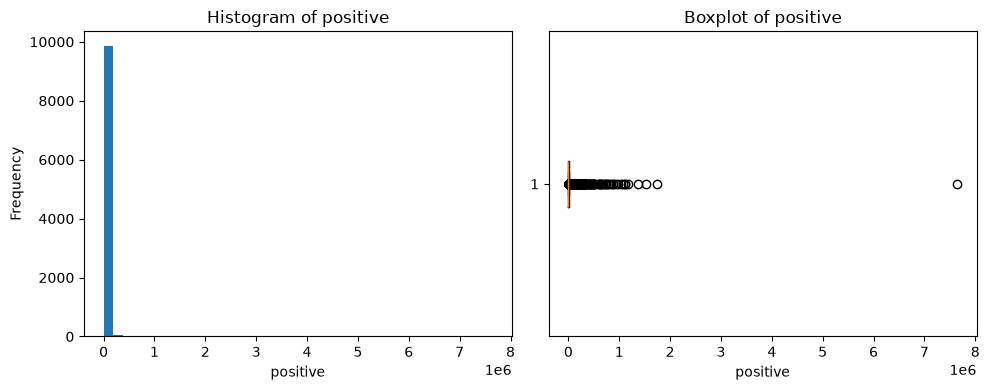

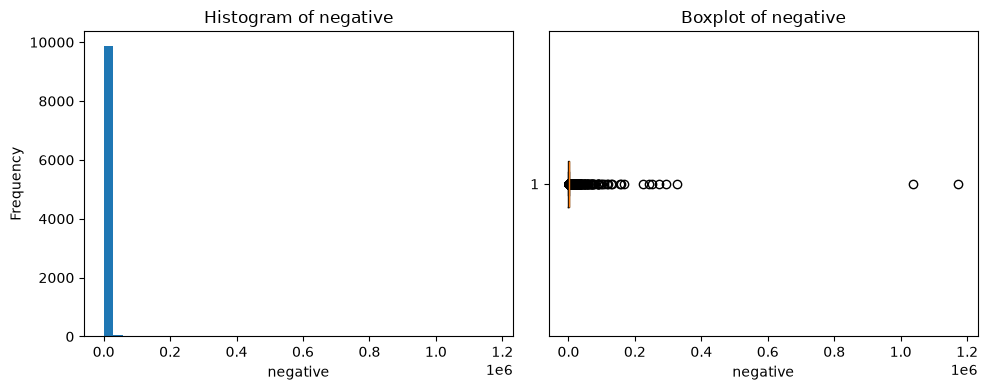

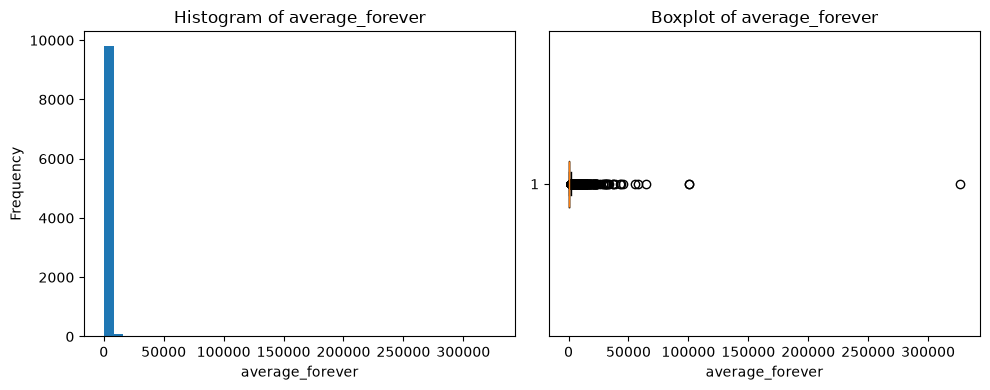

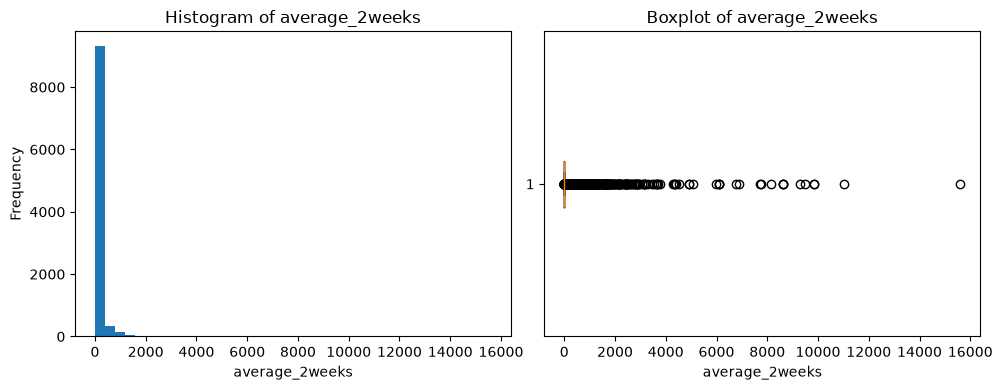

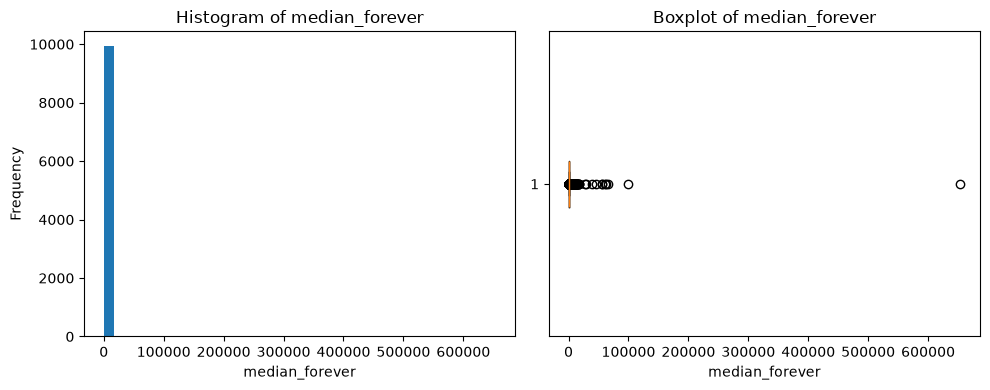

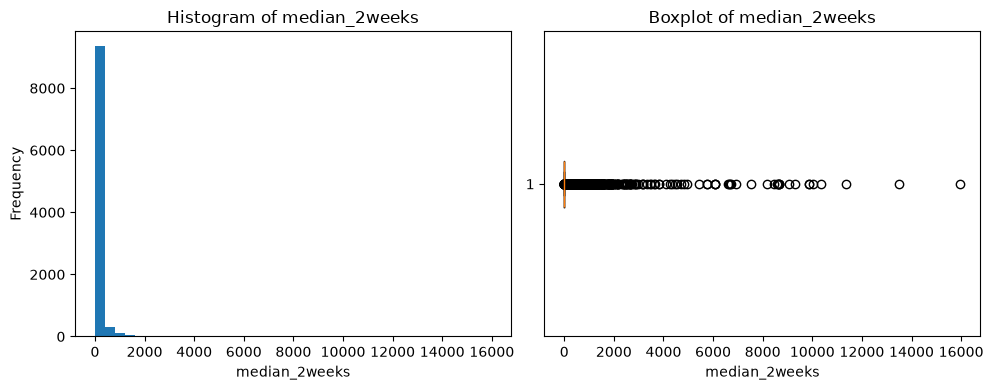

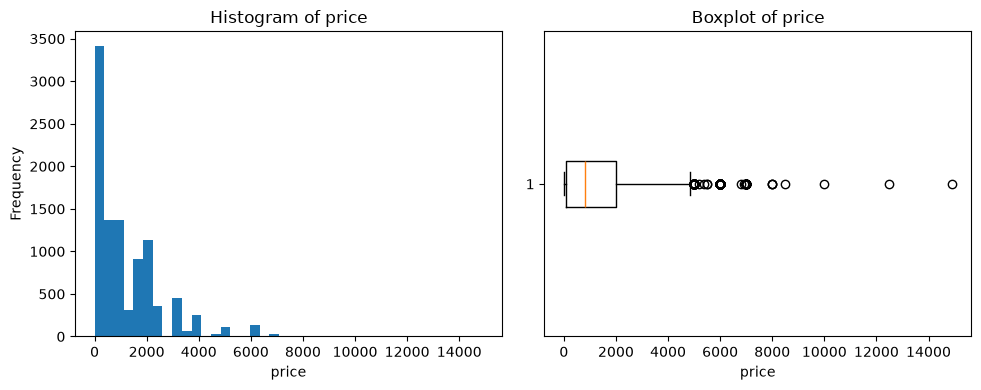

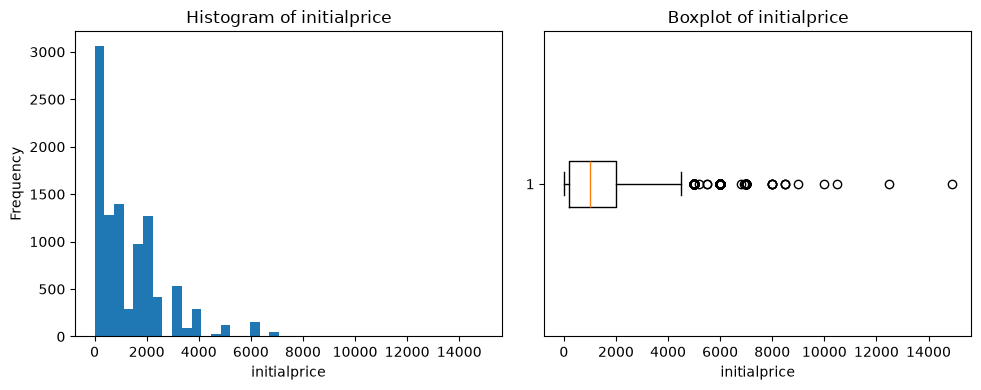

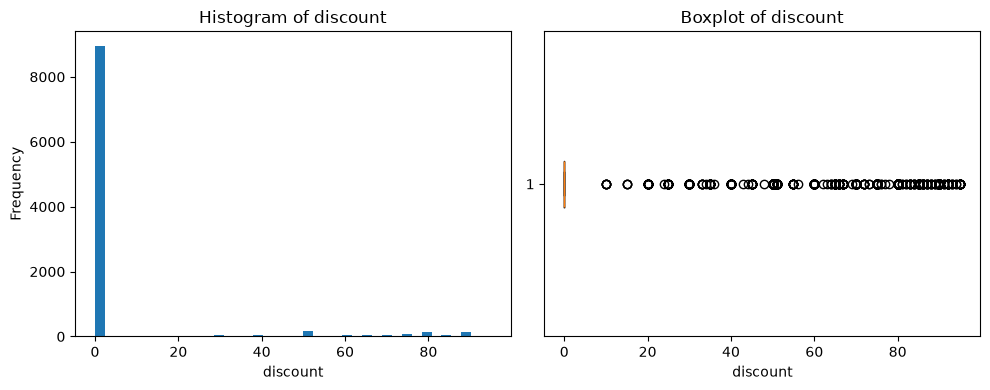

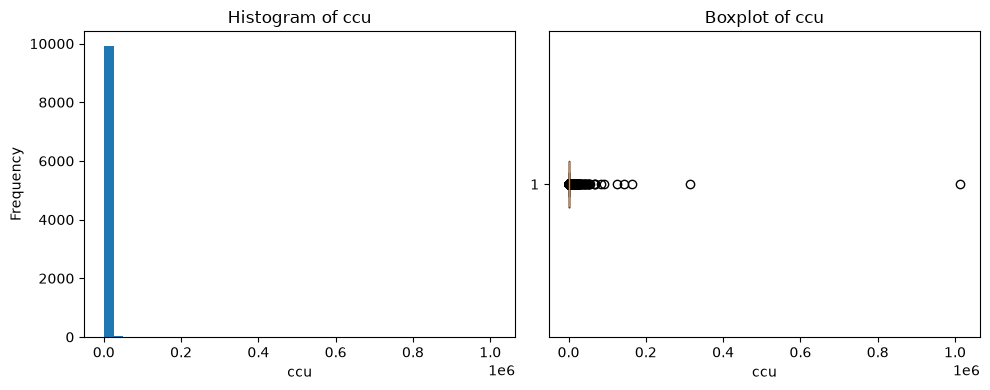

In [13]:
for feature in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(df[feature], bins=40)
    axes[0].set_title(f"Histogram of {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Frequency")

    axes[1].boxplot(df[feature], orientation="horizontal")
    axes[1].set_title(f"Boxplot of {feature}")
    axes[1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

The histograms and boxplots confirm the strong right-skewness observed in the numerical summary.

For several features, most observations are concentrated near relatively small values, while a small number of games have extremely large review counts, playtime, or concurrent player activity.

These extreme observations compress the central part of the distributions and appear as numerous outliers in the boxplots.

However, these observations should not automatically be treated as data errors. In the context of Steam games, unusually popular or highly played games may represent legitimate but rare cases.

#### 3.5.1 Log-Scale Visualization of Highly Skewed Features

Several numerical features contain extreme right tails, causing most observations to be compressed near zero in the original-scale visualizations.

To examine the underlying distributions more clearly, a `log1p` transformation is applied for visualization purposes. This transformation is suitable because it can also handle zero values.

The original values are preserved, and the transformed values are used only to improve the interpretability of the distribution plots at this stage.

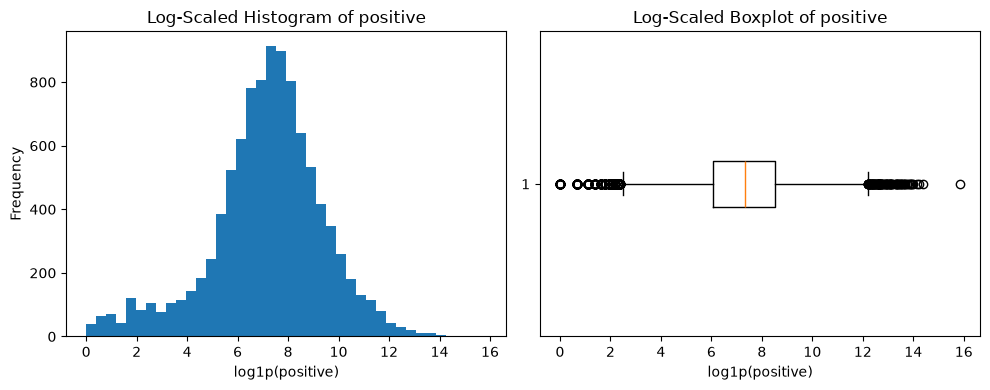

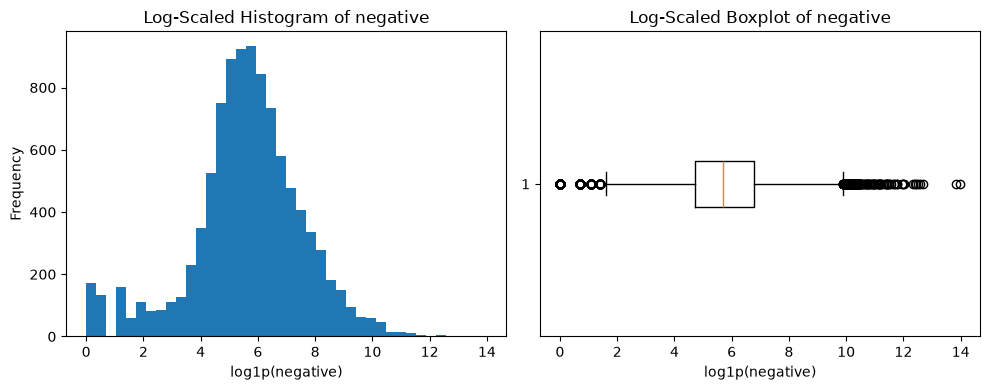

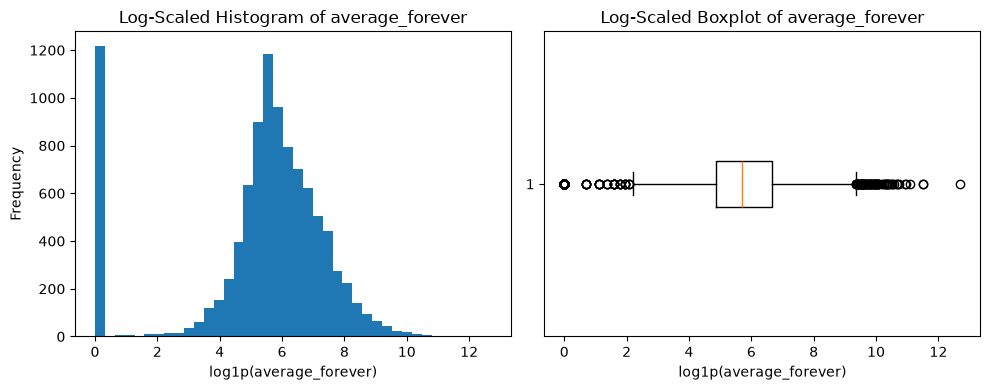

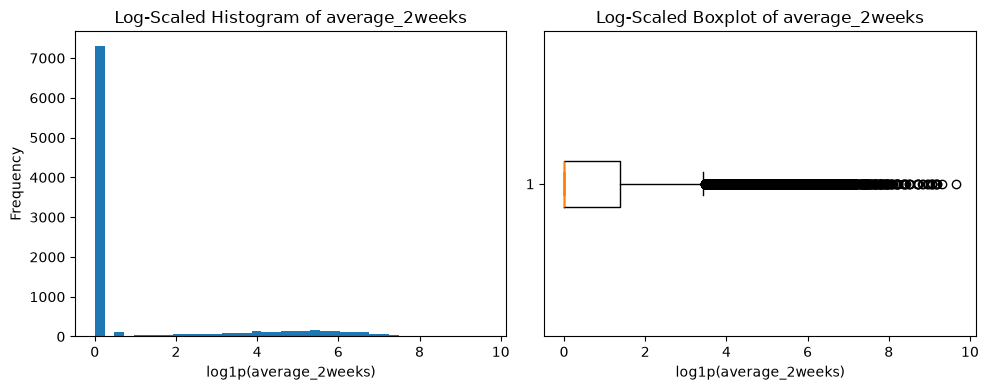

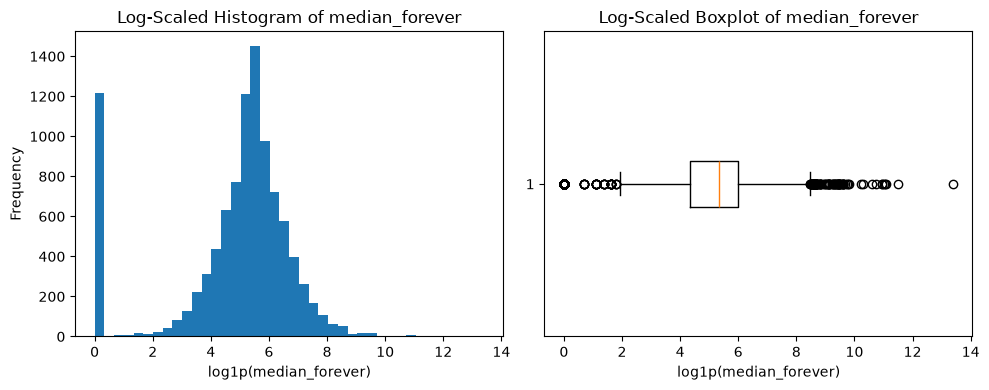

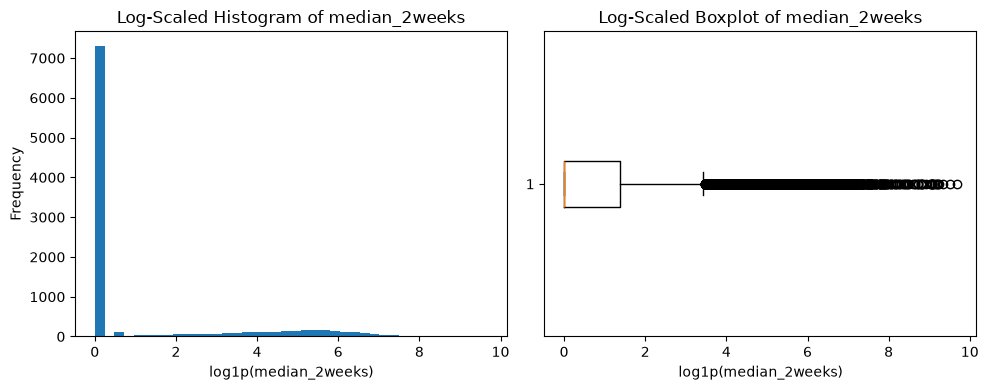

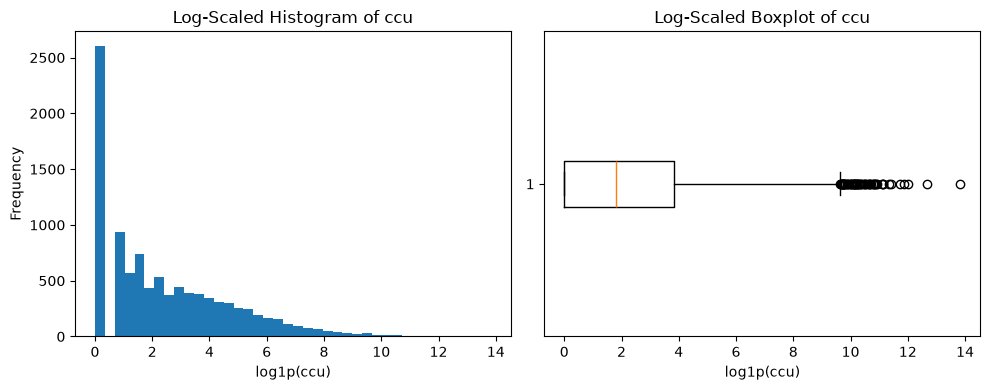

In [14]:
highly_skewed_features = [
    "positive",
    "negative",
    "average_forever",
    "average_2weeks",
    "median_forever",
    "median_2weeks",
    "ccu"
]

for feature in highly_skewed_features:
    log_values = np.log1p(df[feature])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(log_values, bins=40)
    axes[0].set_title(f"Log-Scaled Histogram of {feature}")
    axes[0].set_xlabel(f"log1p({feature})")
    axes[0].set_ylabel("Frequency")

    axes[1].boxplot(log_values, orientation="horizontal")
    axes[1].set_title(f"Log-Scaled Boxplot of {feature}")
    axes[1].set_xlabel(f"log1p({feature})")

    plt.tight_layout()
    plt.show()

The log-transformed visualizations provide a clearer view of the highly skewed numerical features.

For `positive`, `negative`, `average_forever`, and `median_forever`, the transformation substantially reduces the visual dominance of extreme observations and reveals more structured central distributions.

However, features such as `average_2weeks`, `median_2weeks`, and `ccu` remain strongly asymmetric even after transformation. A large proportion of games have zero or very low recent activity, while a smaller number of games exhibit substantially higher activity levels.

This indicates that the dataset contains both heavy-tailed behavior and a strong concentration of low-activity observations. The log transformation improves visualization, but it does not eliminate the underlying non-normal structure of the data.

### 3.6 Correlation Analysis

The relationships between numerical features are examined using a correlation matrix.

This analysis helps identify strongly related variables, possible redundancy, and feature groups that may influence the later PCA and clustering results.

In [15]:
correlation_matrix = df[numerical_features].corr()

correlation_matrix

,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
positive,1.000000,0.805917,0.153237,0.092797,0.017909,0.044313,0.070100,0.075101,0.000676,0.884481
negative,0.805917,1.000000,0.152016,0.085363,0.017593,0.040097,0.054420,0.061601,-0.000089,0.849025
average_forever,0.153237,0.152016,1.000000,0.294981,0.863287,0.272543,0.064040,0.065156,-0.017788,0.139776
average_2weeks,0.092797,0.085363,0.294981,1.000000,0.047342,0.958234,0.103015,0.106832,-0.001412,0.064329
median_forever,0.017909,0.017593,0.863287,0.047342,1.000000,0.044943,0.016851,0.016275,-0.006585,0.018020
median_2weeks,0.044313,0.040097,0.272543,0.958234,0.044943,1.000000,0.087696,0.089865,-0.002303,0.027348
price,0.070100,0.054420,0.064040,0.103015,0.016851,0.087696,1.000000,0.931789,-0.166428,0.025633
initialprice,0.075101,0.061601,0.065156,0.106832,0.016275,0.089865,0.931789,1.000000,0.118421,0.027961
discount,0.000676,-0.000089,-0.017788,-0.001412,-0.006585,-0.002303,-0.166428,0.118421,1.000000,-0.002730
ccu,0.884481,0.849025,0.139776,0.064329,0.018020,0.027348,0.025633,0.027961,-0.002730,1.000000


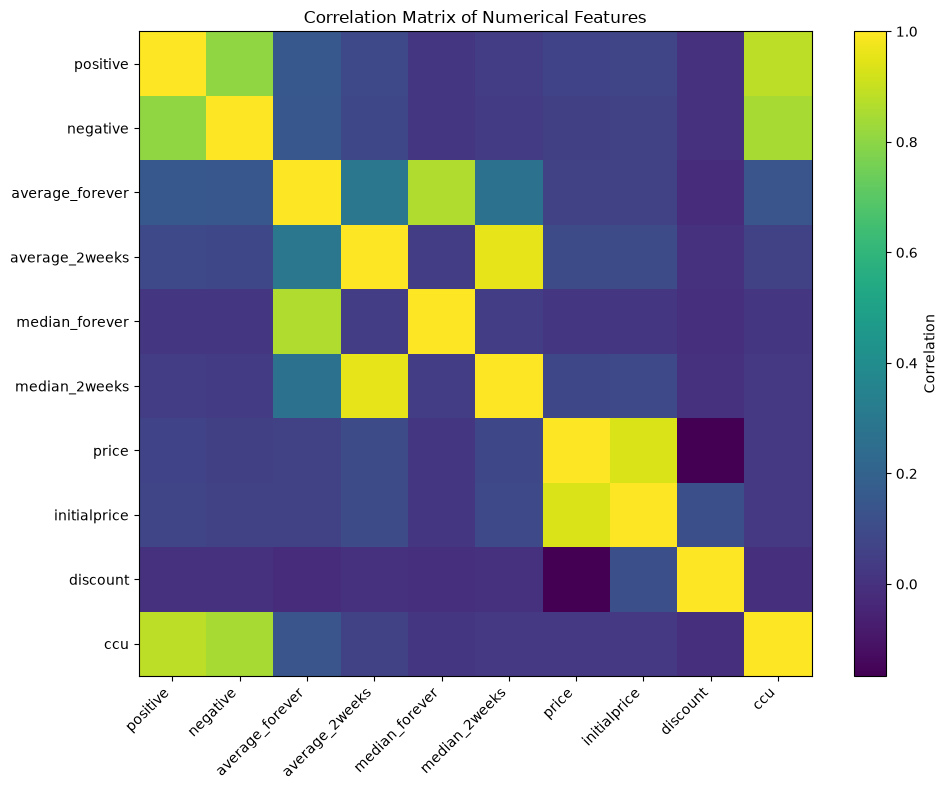

In [16]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numerical_features)),
    numerical_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numerical_features)),
    numerical_features
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

Several strong relationships are visible in the correlation matrix.

The strongest correlation appears between `average_2weeks` and `median_2weeks` (approximately 0.96), indicating that the two recent-playtime measures contain highly related information.

A similarly strong relationship exists between `price` and `initialprice` (approximately 0.93), which is expected because the current price is often derived from the original price and any active discount.

The `average_forever` and `median_forever` features are also strongly correlated (approximately 0.86), suggesting redundancy between the two measures of long-term playtime.

The review and activity variables show strong relationships as well. `positive` reviews are strongly correlated with `ccu` (approximately 0.88), while `negative` reviews are correlated with `ccu` at approximately 0.85. Positive and negative review counts are also strongly correlated with each other (approximately 0.81). This likely reflects differences in game popularity: games with larger player populations tend to accumulate larger numbers of both positive and negative reviews.

Most other relationships are relatively weak.

The presence of several highly correlated feature pairs suggests that the dataset contains redundant information. This is particularly relevant for PCA, which may be able to represent several correlated variables using a smaller number of principal components.

### 3.7 Outlier Exploration

The numerical features are examined for extreme observations, heavy tails, possible noise, and potential data-quality issues.

At this stage, unusual values are treated as potential outliers rather than automatically classified as errors. In the context of Steam games, extreme values may represent legitimate cases such as highly popular games, unusually long playtime, or temporary spikes in player activity.

In [17]:
outlier_summary = []

for feature in numerical_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Outlier Count,Outlier Percentage
0,positive,1372,13.779251
1,negative,1341,13.467912
2,average_forever,1083,10.876770
3,average_2weeks,2335,23.450839
4,median_forever,974,9.782063
5,median_2weeks,2345,23.551270
6,price,290,2.912524
7,initialprice,336,3.374510
8,discount,1003,10.073315
9,ccu,1661,16.681731


In [18]:
extreme_features = [
    "positive",
    "negative",
    "average_forever",
    "ccu"
]

for feature in extreme_features:
    print(f"\nTop 5 games by {feature}:")
    display(
        df[["name", feature]]
        .sort_values(by=feature, ascending=False)
        .head()
    )


Top 5 games by positive:


,name,positive
0,Counter-Strike: Global Offensive,7642084
8,Grand Theft Auto V Legacy,1739980
2,PUBG: BATTLEGROUNDS,1520457
17,Terraria,1373979
24,Tom Clancy's Rainbow Six Siege,1172854



Top 5 games by negative:


,name,negative
0,Counter-Strike: Global Offensive,1173003
2,PUBG: BATTLEGROUNDS,1037487
1,Apex Legends,326926
5,Call of Duty: Modern Warfare II,294520
12,War Thunder,272617



Top 5 games by average_forever:


,name,average_forever
6999,Terminal Hacker,326962
7672,Wizard And Minion Idle,100403
1455,YoloMouse - Game Cursor Changer,100192
7584,Fish Idle 2: Underwater Mystery,65030
5223,Granado Espada,58132



Top 5 games by ccu:


,name,ccu
0,Counter-Strike: Global Offensive,1013936
2,PUBG: BATTLEGROUNDS,314682
479,ELDEN RING NIGHTREIGN,163599
25,Rust,143870
1,Apex Legends,124262


The IQR-based analysis identifies a relatively large number of potential outliers across several numerical features.

In particular, recent playtime measures and `ccu` contain a high proportion of observations outside the traditional 1.5×IQR range. This suggests that the distributions are strongly non-normal and that a simple univariate outlier rule may classify many legitimate observations as unusual.

The most extreme values in review counts and concurrent users correspond to well-known and highly popular games such as Counter-Strike: Global Offensive, PUBG: BATTLEGROUNDS, Grand Theft Auto V, Apex Legends, and Rust. These observations are extreme in a statistical sense, but they are plausible real-world cases rather than obvious data errors.

The `average_forever` feature presents a more ambiguous situation. Some games or applications have exceptionally large reported playtime values, which may reflect idle-game behavior, software running for long periods, or characteristics of the measurement process rather than incorrect data.

Therefore, extreme observations are retained at this stage. They will later be evaluated using multi-dimensional anomaly detection methods rather than removed solely on the basis of univariate thresholds.

In [19]:
sanity_checks = pd.Series({
    "Negative positive-review counts": (df["positive"] < 0).sum(),
    "Negative negative-review counts": (df["negative"] < 0).sum(),
    "Negative average total playtime": (df["average_forever"] < 0).sum(),
    "Negative recent average playtime": (df["average_2weeks"] < 0).sum(),
    "Negative median total playtime": (df["median_forever"] < 0).sum(),
    "Negative recent median playtime": (df["median_2weeks"] < 0).sum(),
    "Negative prices": (df["price"] < 0).sum(),
    "Negative initial prices": (df["initialprice"] < 0).sum(),
    "Discount outside 0-100%": ((df["discount"] < 0) | (df["discount"] > 100)).sum(),
    "Negative CCU": (df["ccu"] < 0).sum()
})

sanity_checks

Negative positive-review counts     0
Negative negative-review counts     0
Negative average total playtime     0
Negative recent average playtime    0
Negative median total playtime      0
Negative recent median playtime     0
Negative prices                     0
Negative initial prices             0
Discount outside 0-100%             0
Negative CCU                        0
dtype: int64

The basic validity checks did not reveal obvious impossible values such as negative review counts, negative playtime, negative prices, invalid discount percentages, or negative concurrent-player counts.

Therefore, no clear data-entry errors were identified through these basic range checks.

However, the absence of impossible values does not guarantee that all observations are completely accurate. Extremely large values, repeated zeros, ownership estimates, and unusually high playtime values may still reflect measurement artifacts, estimation procedures, or unusual but legitimate player behavior.

## 4. Dimensionality Reduction

Before applying PCA, the numerical features are prepared for analysis.

This preprocessing stage converts selected variables into appropriate numerical representations and defines the final feature set used for dimensionality reduction and later unsupervised learning methods.

### 4.1 Feature Preparation

In [20]:
# Convert SteamSpy ownership ranges to numerical midpoint estimates
def owners_midpoint(value):
    lower, upper = value.split(" .. ")
    lower = int(lower.replace(",", ""))
    upper = int(upper.replace(",", ""))
    return (lower + upper) / 2

df["estimated_owners"] = df["owners"].apply(owners_midpoint)

df["price_usd"] = df["price"] / 100
df["initialprice_usd"] = df["initialprice"] / 100

In [21]:
model_features = [
    "positive",
    "negative",
    "average_forever",
    "average_2weeks",
    "median_forever",
    "median_2weeks",
    "price_usd",
    "initialprice_usd",
    "discount",
    "ccu",
    "estimated_owners"
]

In [22]:
df[model_features].head()

,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price_usd,initialprice_usd,discount,ccu,estimated_owners
0,7642084,1173003,34112,731,6777,297,0.00,0.00,0,1013936,150000000.0
1,668053,326926,11025,635,977,256,0.00,0.00,0,124262,150000000.0
2,1520457,1037487,23333,820,5899,335,0.00,0.00,0,314682,150000000.0
3,358266,22443,3930,770,2223,397,22.49,29.99,25,18028,75000000.0
4,1044264,117208,21058,772,4175,161,0.00,0.00,0,43819,75000000.0


The `owners` feature is provided as an estimated interval rather than an exact value. To obtain a numerical representation suitable for unsupervised learning, the midpoint of each ownership range is used as `estimated_owners`.

The `price` and `initialprice` features are stored in cents and are converted to U.S. dollars for easier interpretation.

These transformations preserve the underlying information while producing a consistent numerical feature set for the subsequent analysis.

count    9.957000e+03
mean     9.358391e+05
std      4.207908e+06
min      7.500000e+04
25%      1.500000e+05
50%      3.500000e+05
75%      7.500000e+05
max      1.500000e+08
Name: estimated_owners, dtype: float64
Skewness: 20.290071978928147
Kurtosis: 573.1923345981232


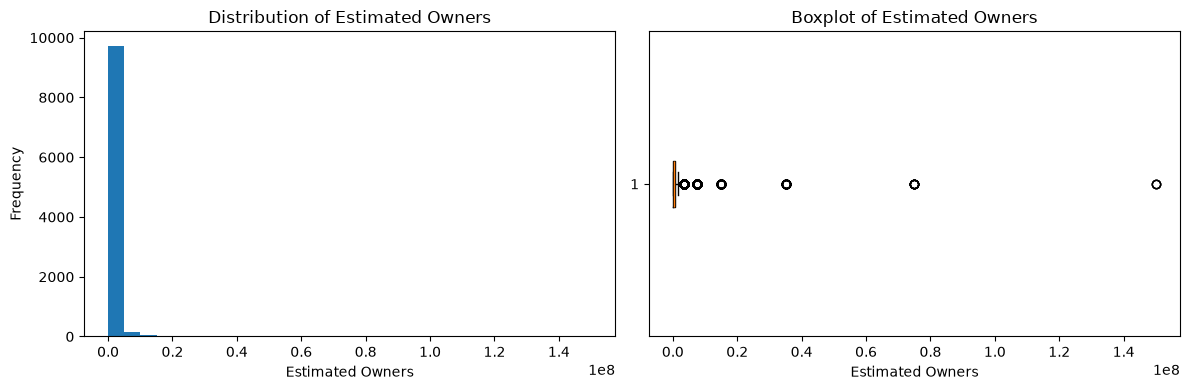

In [23]:
print(df["estimated_owners"].describe())
print("Skewness:", df["estimated_owners"].skew())
print("Kurtosis:", df["estimated_owners"].kurt())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["estimated_owners"], bins=30)
axes[0].set_title("Distribution of Estimated Owners")
axes[0].set_xlabel("Estimated Owners")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df["estimated_owners"], orientation="horizontal")
axes[1].set_title("Boxplot of Estimated Owners")
axes[1].set_xlabel("Estimated Owners")

plt.tight_layout()
plt.show()

The numerical ownership estimate is strongly right-skewed, with most games concentrated in the lower ownership ranges and a relatively small number of games reaching extremely large estimated audiences.

The boxplot therefore identifies several statistically extreme observations. However, these values are plausible in the context of globally popular Steam games and should not automatically be interpreted as data errors.

It should also be remembered that `estimated_owners` is derived from SteamSpy ownership ranges rather than exact ownership counts. Therefore, the numerical midpoint provides a convenient representation for modeling but does not eliminate the uncertainty inherent in the original estimates.

### 4.2 Feature Scaling

The selected numerical features are measured on very different scales.

For example, ownership estimates may reach tens or hundreds of millions, while discount percentages remain below 100. PCA is sensitive to feature scale, so standardization is required to prevent variables with larger numerical ranges from dominating the principal components.

The features are standardized using z-score scaling, giving each feature a mean of approximately zero and a standard deviation of one.

In [24]:
from sklearn.preprocessing import StandardScaler

X = df[model_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=model_features,
    index=df.index
)

X_scaled.head()

,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price_usd,initialprice_usd,discount,ccu,estimated_owners
0,79.837803,64.458096,7.655122,1.318266,0.908176,0.354137,-0.890277,-0.937297,-0.317265,89.587214,35.426545
1,6.862840,17.887368,2.324888,1.118441,0.063435,0.279104,-0.890277,-0.937297,-0.317265,10.935311,35.426545
2,15.782237,56.998870,5.166510,1.503520,0.780299,0.423679,-0.890277,-0.937297,-0.317265,27.769450,35.426545
3,3.621286,1.127670,0.686822,1.399445,0.244909,0.537144,0.823129,1.246533,0.886991,1.543662,17.602067
4,10.799442,6.343832,4.641267,1.403608,0.529208,0.105248,-0.890277,-0.937297,-0.317265,3.823723,17.602067


In [25]:
pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Std": X_scaled.std()
})

,Mean,Std
positive,-1.141778e-17,1.00005
negative,1.141778e-17,1.00005
average_forever,5.708890e-18,1.00005
average_2weeks,0.000000e+00,1.00005
median_forever,4.281668e-18,1.00005
median_2weeks,1.141778e-17,1.00005
price_usd,0.000000e+00,1.00005
initialprice_usd,1.370134e-16,1.00005
discount,-7.849724e-18,1.00005
ccu,-5.708890e-18,1.00005


### 4.3 Principal Component Analysis (PCA)

Principal Component Analysis is applied to the standardized feature matrix in order to reduce dimensionality while preserving as much variance as possible.

PCA constructs new orthogonal variables, called principal components, where each component is a linear combination of the original standardized features.

The explained variance ratio is examined to determine how much information is captured by each component and how many components are required to represent the dataset adequately.

In [26]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

pca_summary

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.312312,0.312312
1,PC2,0.204312,0.516624
2,PC3,0.168058,0.684682
3,PC4,0.143469,0.828150
4,PC5,0.094558,0.922709
5,PC6,0.039330,0.962039
6,PC7,0.017193,0.979232
7,PC8,0.008772,0.988004
8,PC9,0.006086,0.994090
9,PC10,0.003508,0.997598


The PCA results show that the first few principal components capture a substantial portion of the total variance.

The first principal component explains approximately 31.2% of the variance, while the first two components together explain about 51.7%.

Approximately 82.8% of the total variance is captured by the first four components, and more than 92% is captured by the first five components.

This suggests that the original 11-dimensional feature space contains a considerable amount of redundancy and can be represented effectively using a smaller number of principal components.

For this dataset, retaining five principal components provides a reasonable balance between dimensionality reduction and information preservation.

More precisely, the first five principal components preserve approximately 92.27% of the total variance. Therefore, reducing the original 11-dimensional feature space to five principal components results in an information loss of approximately **7.73% of the total variance**.

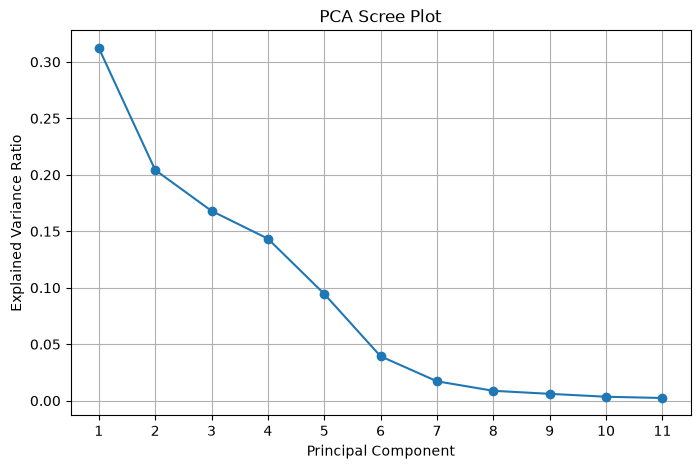

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)

plt.show()

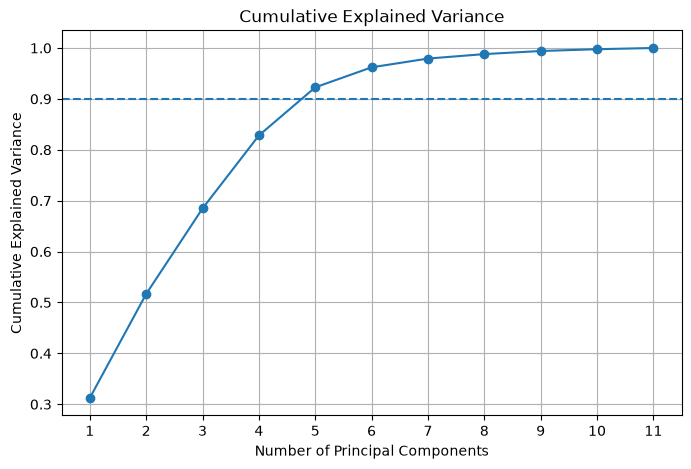

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.90, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)

plt.show()

The scree plot shows a clear decline in the contribution of later principal components.

The cumulative explained variance confirms that five principal components are sufficient to preserve more than 90% of the total variance in the dataset.

Additional components provide relatively small improvements, suggesting diminishing returns beyond the first five principal components.

Therefore, five components are considered an effective reduced representation of the original 11-dimensional feature space.

### 4.4 PCA Projection

The dataset is projected onto the first principal components to visualize its structure in lower-dimensional space.

A two-dimensional projection using PC1 and PC2 and a three-dimensional projection using PC1, PC2, and PC3 are examined.

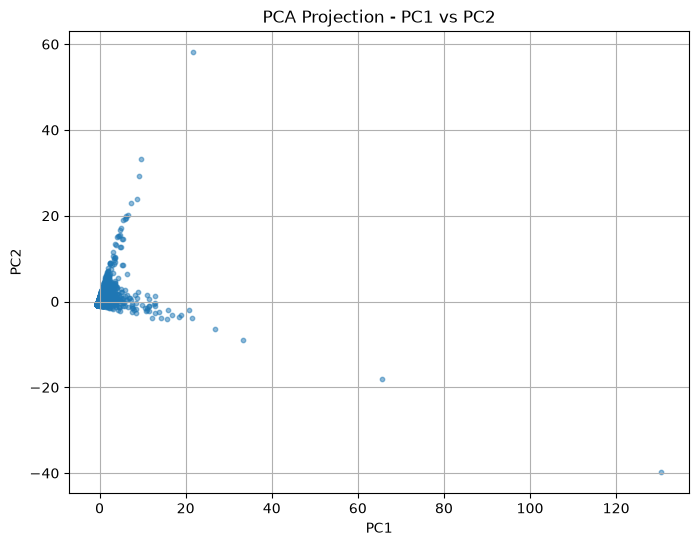

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection - PC1 vs PC2")
plt.grid(True)

plt.show()

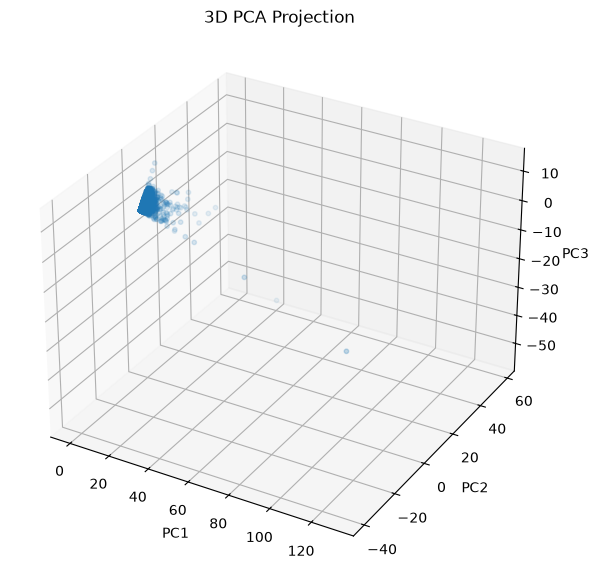

In [30]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    alpha=0.5,
    s=10
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")

plt.show()

The 2D and 3D PCA projections show that most games are concentrated within a relatively compact region of the reduced feature space.

At the same time, several observations are located far from the main concentration of points. These extreme observations are consistent with the heavy-tailed distributions identified earlier and may correspond to unusually popular, highly played, or otherwise atypical games.

No clearly separated cluster structure is immediately visible from the PCA projections alone. Instead, the data appears to contain a dense central region with several extreme observations extending outward.

The 2D projection represents approximately 51.7% of the total variance, while the first three principal components together represent approximately 68.5%. Therefore, these visualizations provide only a partial representation of the original high-dimensional structure and should not be used alone to determine the existence of clusters or anomalies.

### 4.5 Principal Component Interpretation

The contribution of each original feature to the principal components is examined using the PCA component loadings.

Large positive or negative loading values indicate that a feature has a strong influence on the corresponding principal component.

In [31]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=model_features,
    columns=[f"PC{i+1}" for i in range(len(model_features))]
)

loadings.iloc[:, :5]

,PC1,PC2,PC3,PC4,PC5
positive,0.490563,-0.157980,0.011356,-0.015210,0.000724
negative,0.489108,-0.164184,0.002296,-0.015662,-0.000451
average_forever,0.185448,0.392961,-0.318548,0.433910,0.008491
average_2weeks,0.153034,0.489056,-0.136978,-0.455533,-0.006621
median_forever,0.085902,0.307526,-0.314961,0.581682,0.022307
median_2weeks,0.123454,0.493715,-0.143930,-0.463469,-0.008599
price_usd,0.097475,0.293409,0.618250,0.159657,-0.116149
initialprice_usd,0.100518,0.290805,0.613603,0.151648,0.170448
discount,-0.004385,-0.019708,-0.025845,-0.031753,0.978129
ccu,0.474653,-0.180046,-0.015555,-0.012408,-0.005641


The PCA loadings reveal several interpretable patterns in the reduced feature space.

**PC1** is strongly influenced by `positive`, `negative`, `ccu`, and `estimated_owners`. These variables are all related to game popularity and player activity, suggesting that PC1 can be interpreted primarily as a **popularity/activity component**.

**PC2** is influenced mainly by `average_2weeks`, `median_2weeks`, and `average_forever`, with additional contribution from pricing variables. This component appears to represent **player engagement and recent playtime behavior**.

**PC3** is dominated by `price_usd` and `initialprice_usd`, indicating that it primarily captures **pricing-related variation**.

**PC4** contrasts long-term playtime (`average_forever`, `median_forever`) with recent playtime (`average_2weeks`, `median_2weeks`). This suggests that PC4 may capture differences between **historical engagement and recent activity**.

**PC5** is dominated by `discount`, with a loading close to 1. This indicates that discount behavior is largely independent from the other major feature groups and forms a distinct source of variation.

Overall, the principal components separate the original features into meaningful groups related to popularity, engagement, pricing, and discount behavior. This supports the earlier correlation analysis and confirms that the original feature space contains substantial redundancy.

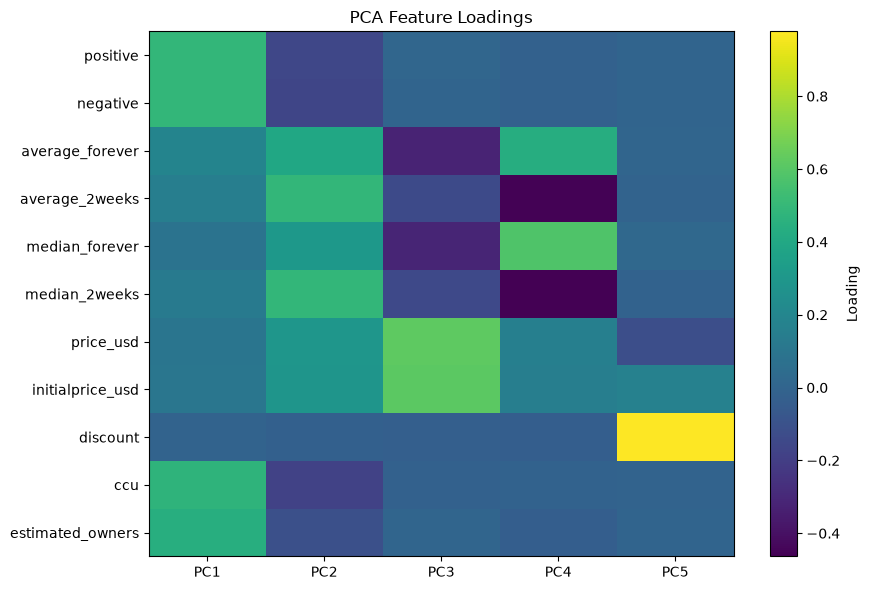

In [32]:
plt.figure(figsize=(9, 6))

plt.imshow(loadings.iloc[:, :5], aspect="auto")
plt.colorbar(label="Loading")

plt.xticks(
    range(5),
    loadings.columns[:5]
)

plt.yticks(
    range(len(model_features)),
    model_features
)

plt.title("PCA Feature Loadings")
plt.tight_layout()
plt.show()

The loading heatmap provides a clear visual summary of the feature contributions to the first five principal components.

Distinct groups of related variables can be observed. Popularity-related features contribute strongly to PC1, pricing variables dominate PC3, and `discount` contributes almost independently to PC5.

The visualization therefore reinforces the interpretation that PCA successfully separates several meaningful dimensions of Steam game behavior while reducing redundancy among correlated original features.

### 4.6 PCA Discussion

PCA is a global linear dimensionality-reduction method because its principal components are determined from the variance structure of the entire dataset. It is therefore effective at identifying dominant global directions of variation, but it does not explicitly preserve local neighborhood relationships.

The 2D and 3D projections reveal several extreme observations, but they do not show strong or clearly separated groups of Steam games. This suggests that the dominant variance directions are influenced more by continuous differences in popularity, engagement, and pricing than by a naturally separated cluster structure.

From a computational perspective, PCA is inexpensive for the current dataset of approximately 10,000 observations and 11 numerical modeling features. It therefore provides a practical way to obtain a more compact representation of the data.

However, PCA is based on variance and covariance structure. Because the dataset contains highly skewed and heavy-tailed variables, extreme observations can influence the orientation of the principal components. This may reduce the stability of the representation if the dataset or extreme observations change substantially.

Interpretability is reduced compared with the original features because each principal component combines several variables. Nevertheless, the loading analysis provides meaningful interpretations related to popularity, player engagement, pricing, and discounts.

Overall, PCA provides a useful reduced representation because the original feature space contains substantial redundancy. However, it should be treated as a complementary representation rather than a complete replacement for the original data, particularly when analyzing local structure or individual anomalies.

## 5. Clustering Analysis

Clustering methods are applied to investigate whether the Steam games dataset contains meaningful groups of observations with similar characteristics.

Three different clustering approaches are examined:

- K-Means
- DBSCAN
- Hierarchical Clustering

These methods rely on different assumptions about cluster structure and therefore may produce different results.

The clustering results will be evaluated quantitatively and visualized in PCA space. In addition, clustering will later be applied to the feature space itself to investigate relationships and redundancy between variables.

### 5.1 K-Means Clustering

K-Means is a centroid-based clustering algorithm that partitions the observations into a predefined number of clusters.

The method attempts to minimize the within-cluster sum of squared Euclidean distances:

\[
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
\]

where \(C_k\) represents cluster \(k\) and \(\mu_k\) is its centroid.

The algorithm repeatedly assigns each observation to the nearest centroid and then recalculates the centroids until the assignments stabilize.

K-Means works best when clusters are relatively compact, approximately convex, and reasonably similar in scale. It also requires the number of clusters \(K\) to be selected in advance.

Its main strengths are simplicity, computational efficiency, and scalability. However, it is sensitive to extreme observations, feature scaling, initialization, and non-spherical cluster structures.

Because the Steam dataset contains strongly skewed and heavy-tailed numerical variables, standardization is used before clustering, and the resulting clusters are interpreted cautiously rather than assuming that a meaningful natural partition must exist.

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

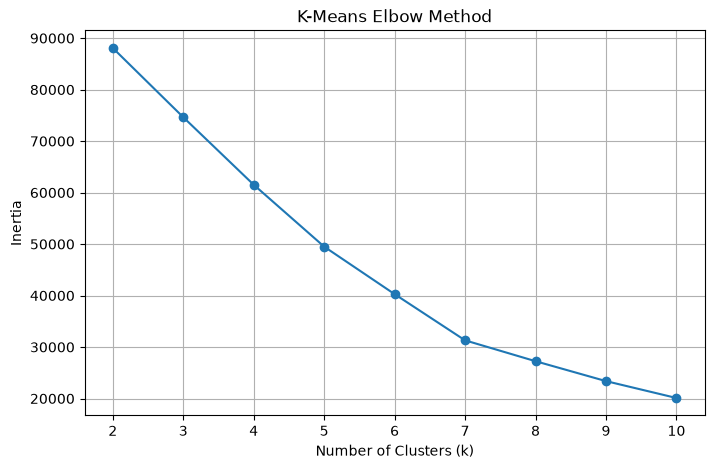

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(k_values)
plt.grid(True)

plt.show()

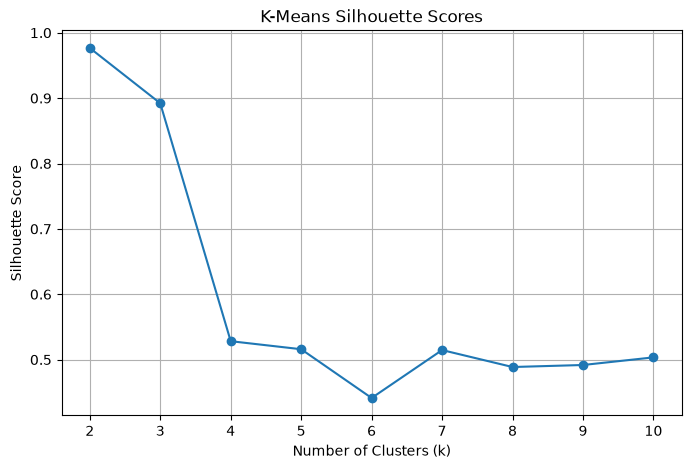

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.xticks(k_values)
plt.grid(True)

plt.show()

The silhouette analysis produces unusually high scores for two and three clusters.

However, given the extreme values and strongly skewed distributions identified during the exploratory analysis, a high silhouette score does not necessarily indicate a meaningful cluster structure. K-Means may isolate a small number of extreme games into separate clusters while placing the majority of observations into one dominant cluster.

Therefore, the cluster sizes and characteristics are examined before selecting the final number of clusters.

In [36]:
for k in [2, 3]:
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_test = kmeans_test.fit_predict(X_scaled)

    cluster_counts = pd.Series(labels_test).value_counts().sort_index()

    print(f"\nCluster sizes for k={k}:")
    print(cluster_counts)


Cluster sizes for k=2:
0    9955
1       2
Name: count, dtype: int64

Cluster sizes for k=3:
0    9917
1       2
2      38
Name: count, dtype: int64


In [37]:
for k in [2, 3]:
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_test = kmeans_test.fit_predict(X_scaled)

    proportions = (
        pd.Series(labels_test)
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(f"\nCluster percentages for k={k}:")
    print(proportions.round(2))


Cluster percentages for k=2:
0    99.98
1     0.02
Name: proportion, dtype: float64

Cluster percentages for k=3:
0    99.60
1     0.02
2     0.38
Name: proportion, dtype: float64


The cluster-size analysis reveals that the very high silhouette scores for small values of `k` are misleading.

For `k=2`, approximately 99.98% of the observations are assigned to a single cluster, while only two games form the second cluster.

For `k=3`, approximately 99.60% of the observations remain in one dominant cluster, while the two remaining clusters contain only a very small number of games.

This indicates that K-Means is primarily separating a few extreme observations rather than discovering balanced and clearly distinct groups of Steam games.

Therefore, the high silhouette scores should not be interpreted as evidence of a strong natural cluster structure. Instead, they reflect the influence of extreme observations and the strong skewness of the dataset.

For the remainder of the analysis, `k=3` is retained as an exploratory solution rather than as evidence that three natural clusters truly exist.

Compared with `k=2`, the three-cluster solution separates an additional small group of observations with unusual playtime and activity characteristics, allowing the effect of extreme observations on K-Means to be examined in greater detail.

The strong imbalance between the clusters is therefore treated as an important result of the analysis rather than ignored.

In [38]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_3.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels

In [39]:
df[df["kmeans_cluster"] != 0][
    ["name", "positive", "negative", "ccu", "estimated_owners", "kmeans_cluster"]
].sort_values(by="kmeans_cluster")

,name,positive,negative,ccu,estimated_owners,kmeans_cluster
0,Counter-Strike: Global Offensive,7642084,1173003,1013936,150000000.0,1
2,PUBG: BATTLEGROUNDS,1520457,1037487,314682,150000000.0,1
48,Paladins,294373,52031,1028,15000000.0,2
81,Half-Life 2,239721,5906,1555,15000000.0,2
112,War Robots,15951,10624,1280,7500000.0,2
207,AdVenture Capitalist,51968,7198,1109,7500000.0,2
262,Crosshair X,29275,2077,41428,3500000.0,2
336,Watch_Dogs 2,68213,14166,863,3500000.0,2
347,Tom Clancy's Ghost Recon Wildlands,77138,19439,1441,3500000.0,2
382,Getting Over It with Bennett Foddy,63479,13524,192,3500000.0,2


The inspection of the K-Means clusters confirms that the smaller clusters are dominated by extreme observations.

Cluster 1 contains only two exceptionally popular games, Counter-Strike: Global Offensive and PUBG: BATTLEGROUNDS, both of which have extremely large values in reviews, concurrent users, and estimated ownership.

Cluster 2 contains a small and heterogeneous group of games with unusual combinations of popularity, activity, ownership, or playtime characteristics.

The remaining observations are concentrated in one dominant cluster. Therefore, the K-Means solution reflects the influence of extreme observations more than a balanced natural segmentation of Steam games.

This result highlights an important limitation of centroid-based clustering when applied to highly skewed and heavy-tailed data.

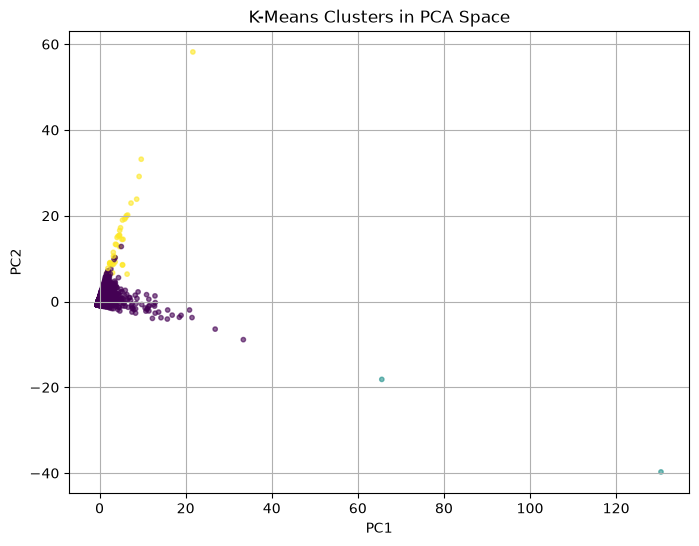

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")
plt.grid(True)

plt.show()

In [41]:
cluster_profile = df.groupby("kmeans_cluster")[model_features].mean()

cluster_profile

,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price_usd,initialprice_usd,discount,ccu,estimated_owners
kmeans_cluster,,,,,,,,,,,
0,1.119187e+04,1.722783e+03,859.249571,75.143491,461.435111,76.508117,11.690185,12.879141,6.603812,426.798629,9.008773e+05
1,4.581270e+06,1.105245e+06,28722.500000,775.500000,6338.000000,316.000000,0.000000,0.000000,0.000000,664309.000000,1.500000e+08
2,3.190908e+04,4.747105e+03,24520.263158,5943.026316,21119.236842,7133.763158,11.126579,11.600263,2.368421,2172.210526,2.214474e+06


The PCA visualization and cluster profiles confirm that the K-Means solution is strongly influenced by extreme observations.

Cluster 0 contains the vast majority of games and represents the main body of the dataset.

Cluster 1 contains only two games and has exceptionally large average values for reviews, concurrent users, estimated ownership, and playtime. This cluster therefore represents extremely popular games rather than a broad category of Steam titles.

Cluster 2 contains a small group of games with particularly high playtime-related values and, in some cases, elevated popularity measures.

Overall, K-Means does not reveal a balanced segmentation of the dataset. Instead, it primarily separates extreme observations from the dense central population. This reflects the sensitivity of centroid-based clustering to highly skewed, heavy-tailed data.

### 5.2 DBSCAN Clustering

DBSCAN is a density-based clustering method that groups observations located in dense regions while labeling isolated observations as noise.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance and does not assume that clusters are spherical or centered around a mean.

The method is controlled mainly by two parameters:

- `eps`: the maximum distance between neighboring observations
- `min_samples`: the minimum number of nearby observations required to form a dense region

This makes DBSCAN particularly useful for datasets containing irregular cluster shapes and potential outliers.

DBSCAN assumes that meaningful groups can be represented as regions of relatively high density separated by lower-density regions.

Its main strengths are that it can discover irregularly shaped clusters, does not require the number of clusters to be selected in advance, and explicitly identifies noise observations.

However, DBSCAN is sensitive to the choice of `eps` and `min_samples`. A value of `eps` that is too small can classify many legitimate observations as noise, while a value that is too large can merge distinct regions into a single cluster.

The method may also struggle when different clusters have substantially different densities. In higher-dimensional spaces, distance relationships become less informative, making the selection of an appropriate neighborhood radius more difficult.

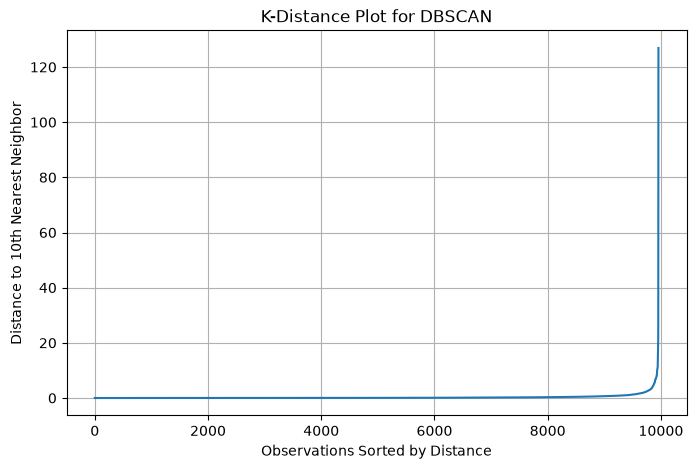

In [42]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)

plt.xlabel("Observations Sorted by Distance")
plt.ylabel(f"Distance to {min_samples}th Nearest Neighbor")
plt.title("K-Distance Plot for DBSCAN")
plt.grid(True)

plt.show()

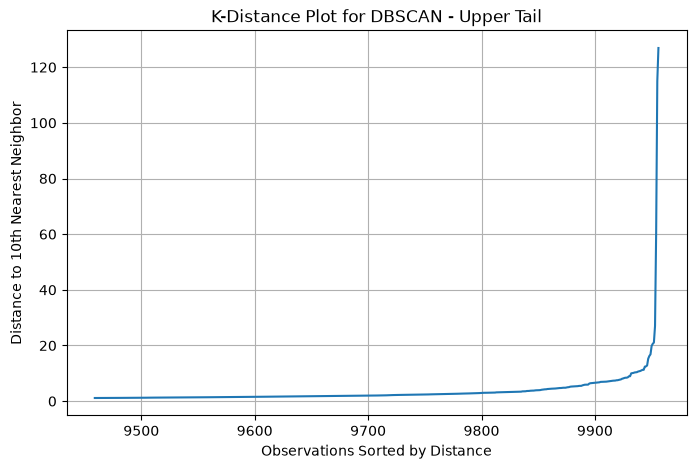

In [43]:
plt.figure(figsize=(8, 5))

start = int(len(k_distances) * 0.95)

plt.plot(
    range(start, len(k_distances)),
    k_distances[start:]
)

plt.xlabel("Observations Sorted by Distance")
plt.ylabel(f"Distance to {min_samples}th Nearest Neighbor")
plt.title("K-Distance Plot for DBSCAN - Upper Tail")
plt.grid(True)

plt.show()

In [44]:
percentiles = [90, 95, 97, 98, 99, 99.5]

for p in percentiles:
    print(
        f"{p}th percentile:",
        np.percentile(k_distances, p)
    )

90th percentile: 0.6294803294895742
95th percentile: 1.1331019167049416
97th percentile: 1.7712228625275888
98th percentile: 2.4594856483844802
99th percentile: 4.258700265189909
99.5th percentile: 6.94905270806741


In [45]:
from sklearn.cluster import DBSCAN

eps_values = [1.5, 2.0, 2.5, 3.0, 4.0]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise} ({n_noise / len(labels) * 100:.2f}%)"
    )

eps=1.5: clusters=1, noise=275 (2.76%)
eps=2.0: clusters=1, noise=189 (1.90%)
eps=2.5: clusters=1, noise=142 (1.43%)
eps=3.0: clusters=1, noise=106 (1.06%)
eps=4.0: clusters=2, noise=78 (0.78%)


The DBSCAN parameter search shows that for `eps` values between 1.5 and 3.0, the algorithm identifies one dominant dense cluster together with a relatively small number of noise observations.

At `eps = 3.0`, approximately 1.06% of the games are labeled as noise, while the remaining observations form a single dense cluster.

Increasing `eps` to 4.0 produces a second cluster, but this may reflect the merging or separation of a small group of observations rather than a clearly distinct natural structure.

Therefore, `eps = 3.0` with `min_samples = 10` is selected as a reasonable balance between identifying isolated observations and preserving the dominant density structure of the dataset.

In [46]:
dbscan = DBSCAN(
    eps=3.0,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = dbscan_labels

In [47]:
pd.Series(dbscan_labels).value_counts().sort_index()

-1     106
 0    9851
Name: count, dtype: int64

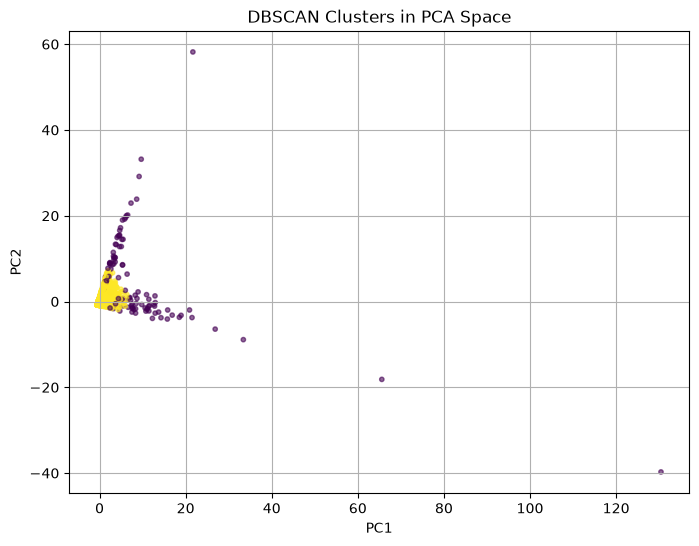

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters in PCA Space")
plt.grid(True)

plt.show()

In [49]:
df[df["dbscan_cluster"] == -1][
    ["name", "positive", "negative", "ccu", "estimated_owners"]
].sort_values(by="ccu", ascending=False).head(20)

,name,positive,negative,ccu,estimated_owners
0,Counter-Strike: Global Offensive,7642084,1173003,1013936,150000000.0
2,PUBG: BATTLEGROUNDS,1520457,1037487,314682,150000000.0
479,ELDEN RING NIGHTREIGN,48901,16771,163599,3500000.0
25,Rust,1071135,156649,143870,35000000.0
1,Apex Legends,668053,326926,124262,150000000.0
19,Wallpaper Engine,876898,17560,91184,35000000.0
1291,DELTARUNE,2804,31,83936,1500000.0
8,Grand Theft Auto V Legacy,1739980,250576,67851,75000000.0
5,Call of Duty: Modern Warfare II,419594,294520,67419,75000000.0
49,NARAKA: BLADEPOINT,225960,98967,66954,15000000.0


The DBSCAN results identify one dominant dense cluster containing 9,851 games and 106 observations labeled as noise.

The PCA visualization shows that most noise points are located away from the dense central region of the dataset.

Many of the detected noise observations correspond to highly popular or unusually active games such as Counter-Strike: Global Offensive, PUBG: BATTLEGROUNDS, Rust, Apex Legends, Grand Theft Auto V, and HELLDIVERS 2.

These observations are therefore not necessarily data errors. Instead, they represent legitimate but statistically unusual games with extreme combinations of popularity, ownership, review counts, or concurrent player activity.

Compared with K-Means, DBSCAN provides a more natural interpretation for this dataset because it can explicitly label isolated observations as noise rather than forcing every game into a cluster.

### 5.3 Hierarchical Clustering

Hierarchical clustering builds a nested structure of observations by progressively merging similar data points or groups of points.

Unlike K-Means, the method does not require the number of clusters to be specified before constructing the hierarchy. The resulting structure can be visualized using a dendrogram, which helps examine possible cluster divisions at different levels of similarity.

Because hierarchical clustering requires pairwise distance calculations and becomes computationally expensive for large datasets, a reproducible random sample of 1,500 games is used for this analysis.

The same standardized feature space used by the previous clustering methods is retained so that differences between the algorithms are not caused by differences in feature scaling.

In this analysis, Ward linkage is used. Ward's method merges the pair of clusters that produces the smallest increase in within-cluster variance at each step.

This approach therefore favors relatively compact groups and relies on Euclidean geometry in the standardized feature space.

A major strength of hierarchical clustering is that it produces a complete hierarchy rather than requiring a final number of clusters before the analysis begins. The dendrogram can therefore be inspected at multiple levels of granularity.

However, hierarchical clustering is computationally more expensive than K-Means for large datasets. It can also be sensitive to extreme observations, and once two groups are merged in agglomerative clustering, the decision cannot later be reversed.

These limitations are particularly relevant to the current dataset because several extreme Steam games are located far from the dense majority of observations.

In [50]:
# Use a reproducible sample because hierarchical clustering is expensive on the full dataset
sample_size = 1500

sample_indices = df.sample(
    n=sample_size,
    random_state=42
).index

X_hierarchical = X_scaled.loc[sample_indices]

In [51]:
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(
    X_hierarchical,
    method="ward"
)

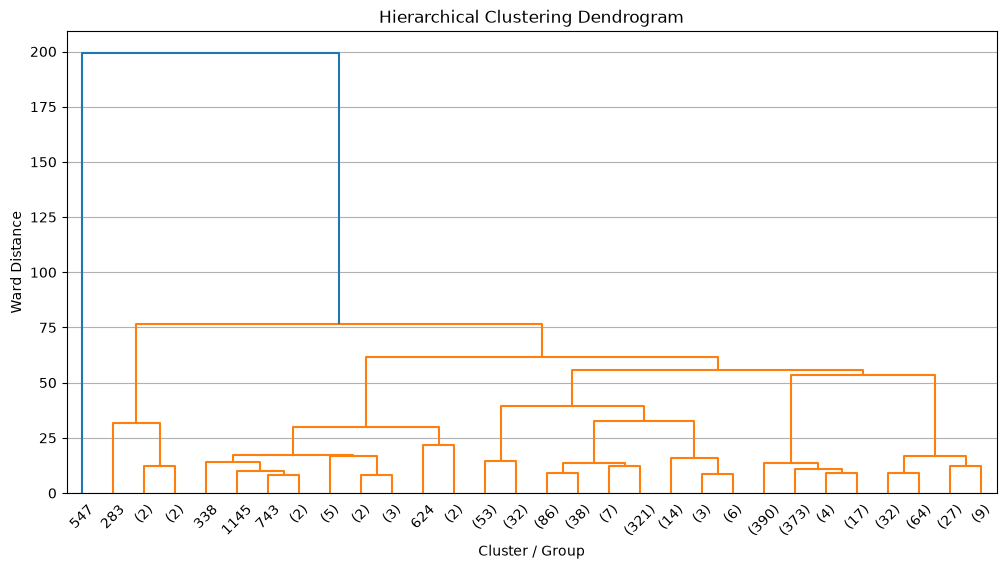

In [52]:
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True
)

plt.xlabel("Cluster / Group")
plt.ylabel("Ward Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.grid(axis="y")

plt.show()

The dendrogram shows a large increase in Ward distance at the final merge, from approximately 75 to nearly 200.

This suggests that a two-cluster solution may represent a meaningful high-level division of the sampled observations.

However, given the extreme observations identified earlier, the resulting cluster sizes must be examined before interpreting this division as a natural segmentation of the dataset.

In [53]:
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(
    linkage_matrix,
    t=2,
    criterion="maxclust"
)

hierarchical_counts = pd.Series(hierarchical_labels).value_counts().sort_index()

hierarchical_counts

1    1499
2       1
Name: count, dtype: int64

In [54]:
hierarchical_percentages = (
    pd.Series(hierarchical_labels)
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

hierarchical_percentages.round(2)

1    99.93
2     0.07
Name: proportion, dtype: float64

The two-cluster hierarchical solution is extremely unbalanced.

Out of the 1,500 sampled observations, 1,499 games are assigned to one cluster, while only a single game forms the second cluster.

Therefore, the large final linkage distance in the dendrogram does not indicate two broad natural groups. Instead, it reflects the separation of one extreme observation from the rest of the sampled dataset.

This result is consistent with the earlier K-Means and DBSCAN analyses, which also showed that extreme observations strongly influence the apparent cluster structure.

In [55]:
hierarchical_results = df.loc[sample_indices].copy()
hierarchical_results["hierarchical_cluster"] = hierarchical_labels

hierarchical_results[
    hierarchical_results["hierarchical_cluster"] == 2
][
    ["name", "positive", "negative", "average_forever",
     "average_2weeks", "ccu", "estimated_owners"]
]

,name,positive,negative,average_forever,average_2weeks,ccu,estimated_owners
0,Counter-Strike: Global Offensive,7642084,1173003,34112,731,1013936,150000000.0


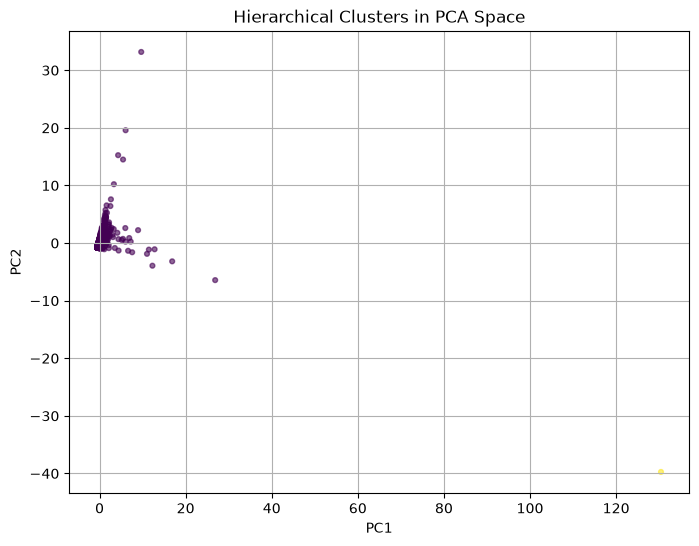

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[sample_indices, 0],
    X_pca[sample_indices, 1],
    c=hierarchical_labels,
    s=12,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters in PCA Space")
plt.grid(True)

plt.show()

The isolated hierarchical cluster consists only of Counter-Strike: Global Offensive.

This game also appeared as an extreme observation in the K-Means and DBSCAN analyses, indicating strong agreement between the different clustering methods regarding its unusual position in the dataset.

The PCA visualization confirms this result: the isolated game lies far from the dense central region of the sampled observations.

Therefore, the hierarchical clustering result does not reveal two broad natural groups. Instead, it highlights the strong influence of a single extreme observation on distance-based clustering.

### 5.4 Feature-Space Clustering

Clustering is now applied to the feature space rather than to the individual games.

Instead of grouping observations with similar characteristics, the transposed standardized data matrix is used to group features that behave similarly across the dataset.

This analysis can reveal groups of related or redundant variables, isolated features, and relationships that may not be immediately visible when clustering the observations directly.

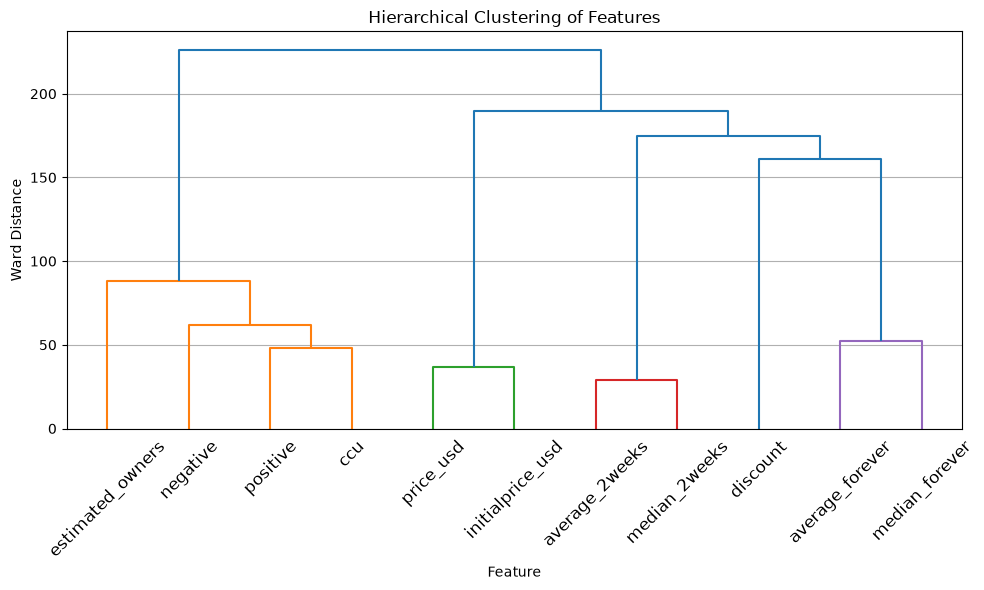

In [57]:
feature_linkage = linkage(
    X_scaled.T,
    method="ward"
)

plt.figure(figsize=(10, 6))

dendrogram(
    feature_linkage,
    labels=model_features,
    leaf_rotation=45
)

plt.xlabel("Feature")
plt.ylabel("Ward Distance")
plt.title("Hierarchical Clustering of Features")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

The feature-space dendrogram reveals several clear groups of related variables.

The popularity-related features `positive`, `negative`, `ccu`, and `estimated_owners` form a closely related group, indicating that games with larger audiences tend to exhibit higher review counts, ownership estimates, and concurrent player activity.

The pricing features `price_usd` and `initialprice_usd` form a distinct pair, reflecting the strong relationship between current and original game prices.

The recent engagement features `average_2weeks` and `median_2weeks` also cluster together, while `average_forever` and `median_forever` form a separate long-term engagement group.

The `discount` feature appears relatively isolated from the other variables, suggesting that discount behavior contains information that is less strongly related to the main popularity, engagement, and pricing patterns.

Overall, feature-space clustering confirms the redundancy and feature groupings previously identified by the correlation matrix and PCA loadings.

Compared with clustering the individual games, feature-space clustering provides a different and clearer type of structural information. Sample clustering was strongly influenced by a small number of extreme games, whereas feature clustering reveals relationships between the measurements themselves.

This makes it possible to identify redundant groups of variables and potential feature hierarchies even when the observations do not form well-separated clusters.

Feature-space clustering can be particularly useful in high-dimensional domains containing many correlated measurements, such as sensor systems, financial indicators, medical measurements, biological or gene-expression data, and large telemetry datasets. In these applications, groups of related features may represent the same underlying phenomenon and may therefore be candidates for dimensionality reduction or feature selection.

### 5.5 Clustering Variance Evaluation

The clustering methods are now evaluated by comparing within-cluster variance with the global variance of the standardized feature space.

A useful clustering solution should generally produce groups that are more internally homogeneous than the complete dataset. However, variance reduction alone may be misleading when cluster sizes are extremely unbalanced or when a method primarily isolates a small number of extreme observations.

Therefore, the variance comparison is interpreted together with cluster sizes, silhouette scores, PCA visualizations, and the qualitative structure of the resulting groups.

In [58]:
def within_cluster_variance_summary(X, labels, ignore_label=None):
    labels_series = pd.Series(labels, index=X.index)

    if ignore_label is not None:
        valid_mask = labels_series != ignore_label
        X = X.loc[valid_mask]
        labels_series = labels_series.loc[valid_mask]

    cluster_rows = []

    for cluster_id in sorted(labels_series.unique()):
        cluster_data = X.loc[labels_series == cluster_id]

        mean_feature_variance = (
            cluster_data.var(ddof=0).mean()
            if len(cluster_data) > 1
            else 0.0
        )

        cluster_rows.append({
            "Cluster": cluster_id,
            "Cluster Size": len(cluster_data),
            "Mean Feature Variance": mean_feature_variance
        })

    cluster_details = pd.DataFrame(cluster_rows)

    weighted_variance = np.average(
        cluster_details["Mean Feature Variance"],
        weights=cluster_details["Cluster Size"]
    )

    return weighted_variance, cluster_details


global_variance = X_scaled.var(ddof=0).mean()
hierarchical_global_variance = X_hierarchical.var(ddof=0).mean()

kmeans_variance, kmeans_variance_details = within_cluster_variance_summary(
    X_scaled,
    kmeans_labels
)

dbscan_variance, dbscan_variance_details = within_cluster_variance_summary(
    X_scaled,
    dbscan_labels,
    ignore_label=-1
)

hierarchical_variance, hierarchical_variance_details = within_cluster_variance_summary(
    X_hierarchical,
    hierarchical_labels
)

variance_comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical Clustering"
    ],
    "Average Within-Cluster Variance": [
        kmeans_variance,
        dbscan_variance,
        hierarchical_variance
    ],
    "Reference Global Variance": [
        global_variance,
        global_variance,
        hierarchical_global_variance
    ]
})

variance_comparison["Variance Ratio"] = (
    variance_comparison["Average Within-Cluster Variance"] /
    variance_comparison["Reference Global Variance"]
)

variance_comparison

,Method,Average Within-Cluster Variance,Reference Global Variance,Variance Ratio
0,K-Means,0.681512,1.000000,0.681512
1,DBSCAN,0.354749,1.000000,0.354749
2,Hierarchical Clustering,0.771399,1.974903,0.390601


In [59]:
print("K-Means cluster variances:")
display(kmeans_variance_details)

print("DBSCAN cluster variances (noise excluded):")
display(dbscan_variance_details)

print("Hierarchical cluster variances:")
display(hierarchical_variance_details)

K-Means cluster variances:


,Cluster,Cluster Size,Mean Feature Variance
0,0,9917,0.486843
1,1,2,181.510006
2,2,38,41.967723


DBSCAN cluster variances (noise excluded):


,Cluster,Cluster Size,Mean Feature Variance
0,0,9851,0.354749


Hierarchical cluster variances:


,Cluster,Cluster Size,Mean Feature Variance
0,1,1499,0.771913
1,2,1,0.000000


The variance analysis must be interpreted carefully because all three clustering solutions are strongly unbalanced.

For K-Means, the weighted average within-cluster variance is lower than the global variance. However, this result is dominated by the very large main cluster, while the two small clusters individually contain much larger feature variance. Therefore, the overall variance reduction should not be interpreted as evidence that all clusters are internally homogeneous or meaningful.

For DBSCAN, the selected parameter configuration produces one dominant non-noise cluster and a relatively small set of observations labeled as noise. Because only one main cluster is present, within-cluster variance is not an effective measure of cluster separation in this case.

The hierarchical solution is even more unbalanced, with nearly all sampled observations assigned to one cluster and a single extreme observation forming another cluster. A singleton cluster has zero internal variance, which can artificially improve a variance-based metric without providing meaningful real-world structure.

Therefore, average within-cluster variance is informative but is not sufficient as a standalone evaluation metric for this dataset. Cluster sizes, silhouette scores, PCA projections, density structure, and real-world interpretation provide essential additional information.

### 5.6 Comparison of Clustering Methods

The three clustering methods produce different results because they define cluster structure in fundamentally different ways.

K-Means is centroid-based and favors compact groups around cluster centers. In this dataset, its solution is strongly influenced by globally extreme games, resulting in one dominant cluster and several very small clusters.

DBSCAN is density-based. Instead of forcing every observation into a cluster, it identifies one dense central population and labels sufficiently isolated observations as noise. This behavior is more consistent with the continuous and heavy-tailed structure observed in the Steam data.

Hierarchical clustering constructs a nested sequence of merges. With Ward linkage, extreme observations remain separated until very late in the hierarchy, producing large linkage distances that may appear to indicate cluster structure even when they primarily reflect individual outliers.

The methods are also sensitive to different hyperparameters. K-Means depends on the selected number of clusters \(K\), DBSCAN depends strongly on `eps` and `min_samples`, and hierarchical clustering depends on the linkage rule and the level at which the dendrogram is cut.

Cluster geometry therefore plays an important role. K-Means is most appropriate for compact centroid-like groups, while DBSCAN can detect irregular density-based regions. Hierarchical clustering provides a flexible hierarchy but does not guarantee that any particular cut represents meaningful real-world categories.

For this dataset, none of the three methods provides strong evidence for a balanced natural segmentation of Steam games. This is an important result rather than a failure: the observations appear to vary continuously, with a dense majority and several extreme games rather than several clearly separated populations.

## 6. Multi-Dimensional Anomaly Detection

This section applies and compares three anomaly detection methods:

- Z-Score
- Isolation Forest
- Local Outlier Factor (LOF)

The objective is not only to identify unusual observations, but also to examine how different assumptions and definitions of abnormality affect the detected anomalies.

### 6.1 Z-Score Method

The Z-score measures how many standard deviations an observation lies from the mean of a feature.

For a feature value \(x\), the Z-score is defined as:

\[
z = \frac{x - \mu}{\sigma}
\]

where \(\mu\) is the feature mean and \(\sigma\) is the standard deviation.

A common rule considers observations with an absolute Z-score greater than 3 as potential outliers.

Because the dataset contains multiple numerical features, an observation is considered anomalous here if at least one feature has an absolute Z-score greater than 3.

In [60]:
z_scores = np.abs(X_scaled)

zscore_anomaly_mask = (z_scores > 3).any(axis=1)

df["zscore_anomaly"] = zscore_anomaly_mask

print("Z-score anomalies:", zscore_anomaly_mask.sum())
print(
    "Percentage:",
    round(zscore_anomaly_mask.mean() * 100, 2),
    "%"
)

Z-score anomalies: 979
Percentage: 9.83 %


In [61]:
zscore_exceed_count = (z_scores > 3).sum(axis=1)

df["zscore_exceed_count"] = zscore_exceed_count

df[df["zscore_anomaly"]][
    ["name", "zscore_exceed_count"] + model_features
].sort_values(
    by="zscore_exceed_count",
    ascending=False
).head(20)

,name,zscore_exceed_count,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price_usd,initialprice_usd,discount,ccu,estimated_owners
0,Counter-Strike: Global Offensive,5,7642084,1173003,34112,731,6777,297,0.00,0.00,0,1013936,150000000.0
2,PUBG: BATTLEGROUNDS,5,1520457,1037487,23333,820,5899,335,0.00,0.00,0,314682,150000000.0
4,Team Fortress 2,5,1044264,117208,21058,772,4175,161,0.00,0.00,0,43819,75000000.0
5,Call of Duty: Modern Warfare II,5,419594,294520,5752,426,665,181,38.49,69.99,45,67419,75000000.0
8,Grand Theft Auto V Legacy,5,1739980,250576,14086,900,5576,120,0.00,0.00,0,67851,75000000.0
95,DayZ,5,330349,99903,15612,1291,2426,472,49.99,49.99,0,37066,15000000.0
37,Cyberpunk 2077,5,713071,131850,5218,399,3008,113,59.99,59.99,0,22265,35000000.0
57,Red Dead Redemption 2,5,676667,56875,5364,639,1766,174,59.99,59.99,0,29885,15000000.0
16,ELDEN RING,5,981540,75137,8273,503,5578,110,59.99,59.99,0,29529,35000000.0
20,Baldur's Gate 3,5,736688,23974,7947,732,4834,264,59.99,59.99,0,54771,35000000.0


The Z-score method identifies 979 observations as anomalous, corresponding to approximately 9.83% of the dataset.

Many of the most extreme observations are well-known and highly popular games such as Counter-Strike: Global Offensive, PUBG: BATTLEGROUNDS, Grand Theft Auto V, Rust, and ELDEN RING. Several of these games exceed the Z-score threshold in multiple numerical features simultaneously.

These results should not be interpreted as evidence that the observations are incorrect. Instead, they demonstrate an important limitation of the Z-score method for this dataset.

The method assumes that extreme deviations from the mean are unusual, but many Steam-related variables are strongly right-skewed and heavy-tailed rather than normally distributed. As a result, legitimate high-popularity or high-engagement games may be classified as anomalies.

This also illustrates a difficulty of applying feature-wise Z-score detection in multiple dimensions: an observation is labeled anomalous if any one of many features exceeds the threshold, increasing the probability that an observation will be flagged.

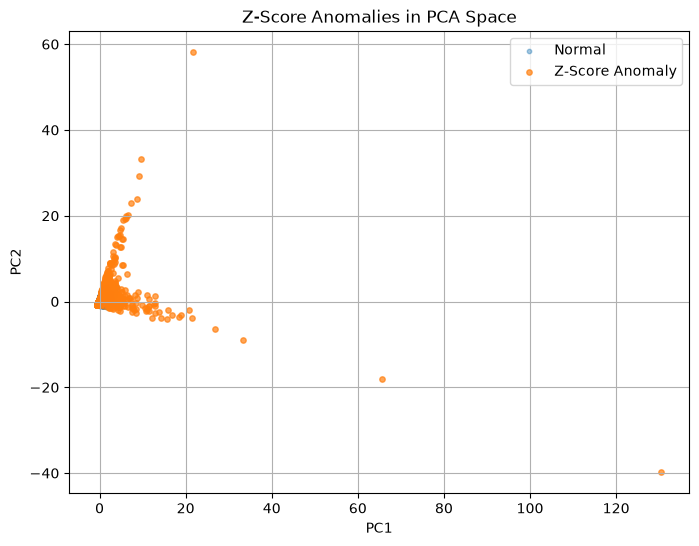

In [62]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[~zscore_anomaly_mask, 0],
    X_pca[~zscore_anomaly_mask, 1],
    s=10,
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    X_pca[zscore_anomaly_mask, 0],
    X_pca[zscore_anomaly_mask, 1],
    s=15,
    alpha=0.7,
    label="Z-Score Anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Z-Score Anomalies in PCA Space")
plt.legend()
plt.grid(True)

plt.show()

The PCA visualization shows that Z-score anomalies are not limited to only the most distant observations.

Many extreme points in PCA space are correctly identified as unusual, but additional observations within or near the dense central region are also flagged.

This reflects the feature-wise nature of the Z-score rule: a game is classified as anomalous whenever at least one numerical feature exceeds the selected threshold, even if the game is not globally isolated in the multidimensional feature space.

The result further illustrates why the Z-score method may produce many false positives when applied to strongly skewed and non-Gaussian data.

### 6.2 Isolation Forest

Isolation Forest detects anomalies by repeatedly partitioning the feature space using randomly selected features and split values.

Observations that are isolated after relatively few random splits are considered more anomalous, because unusual points tend to be easier to separate from the majority of the data.

Unlike the Z-score method, Isolation Forest evaluates observations in a multidimensional context and does not require the features to follow a Gaussian distribution.

The `contamination` parameter controls the expected proportion of anomalous observations and therefore influences the final classification threshold.

The mathematical anomaly score is based on the average path length required to isolate an observation across the trees:

\[
s(x,n) = 2^{-\frac{E[h(x)]}{c(n)}}
\]

where \(h(x)\) is the path length required to isolate observation \(x\), \(E[h(x)]\) is its average path length across the isolation trees, and \(c(n)\) is a normalization factor that depends on the sample size.

Observations that require shorter paths to isolate receive stronger anomaly scores because they can be separated from the rest of the data more easily.

Isolation Forest is generally well suited to multidimensional data because it does not rely directly on pairwise distance calculations and does not assume Gaussian feature distributions. It is also relatively scalable because each tree is built using random partitions.

However, its results still depend on the selected features, the random partitioning process, and the contamination threshold. In very high-dimensional datasets, irrelevant features may reduce the probability that informative variables are selected during the random splits.

For the theoretical anomaly score \(s(x,n)\), values closer to 1 indicate observations that are easier to isolate and are therefore more anomalous, while lower values correspond to more typical observations.

This theoretical score should be distinguished from the scikit-learn `decision_function` used in the code below.

In the scikit-learn implementation used here, the `decision_function` is shifted so that lower and particularly negative values represent more anomalous observations.

In [63]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

iforest_labels = isolation_forest.fit_predict(X_scaled)
iforest_scores = isolation_forest.decision_function(X_scaled)

df["iforest_anomaly"] = iforest_labels == -1
df["iforest_score"] = iforest_scores

print("Isolation Forest anomalies:", df["iforest_anomaly"].sum())
print(
    "Percentage:",
    round(df["iforest_anomaly"].mean() * 100, 2),
    "%"
)

Isolation Forest anomalies: 498
Percentage: 5.0 %


In [64]:
df[df["iforest_anomaly"]][
    ["name", "iforest_score"] + model_features
].sort_values(
    by="iforest_score"
).head(20)

,name,iforest_score,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price_usd,initialprice_usd,discount,ccu,estimated_owners
0,Counter-Strike: Global Offensive,-0.268226,7642084,1173003,34112,731,6777,297,0.00,0.00,0,1013936,150000000.0
2,PUBG: BATTLEGROUNDS,-0.260017,1520457,1037487,23333,820,5899,335,0.00,0.00,0,314682,150000000.0
25,Rust,-0.248002,1071135,156649,23915,1176,2884,392,23.99,39.99,40,143870,35000000.0
8,Grand Theft Auto V Legacy,-0.247054,1739980,250576,14086,900,5576,120,0.00,0.00,0,67851,75000000.0
1455,YoloMouse - Game Cursor Changer,-0.242137,2159,177,100192,6102,55923,7526,3.99,3.99,0,8493,750000.0
24,Tom Clancy's Rainbow Six Siege,-0.233987,1172854,225730,14592,401,2471,127,19.99,19.99,0,51847,35000000.0
7584,Fish Idle 2: Underwater Mystery,-0.233147,712,327,65030,11029,15013,13480,0.00,0.00,0,3589,150000.0
4,Team Fortress 2,-0.233062,1044264,117208,21058,772,4175,161,0.00,0.00,0,43819,75000000.0
32,PAYDAY 2,-0.231644,594327,68755,9784,2389,548,1718,9.99,9.99,0,27254,35000000.0
16,ELDEN RING,-0.226956,981540,75137,8273,503,5578,110,59.99,59.99,0,29529,35000000.0


The Isolation Forest method identifies 498 anomalies, corresponding to exactly 5% of the dataset, as specified by the `contamination` parameter.

Many of the highest-ranked anomalies are highly popular games such as Counter-Strike: Global Offensive, PUBG: BATTLEGROUNDS, Rust, Grand Theft Auto V, and Apex Legends.

However, the method also identifies less popular games with unusual combinations of playtime, ownership, pricing, or activity characteristics.

This demonstrates an important difference from the Z-score method. Isolation Forest evaluates observations in the multidimensional feature space rather than testing each feature independently.

The anomaly score reflects how easily an observation can be isolated through random partitioning. Lower decision-function scores indicate more anomalous observations.

Because the method does not assume Gaussian feature distributions, it is better suited than the classical Z-score approach to the strongly skewed and heavy-tailed structure observed in this dataset.

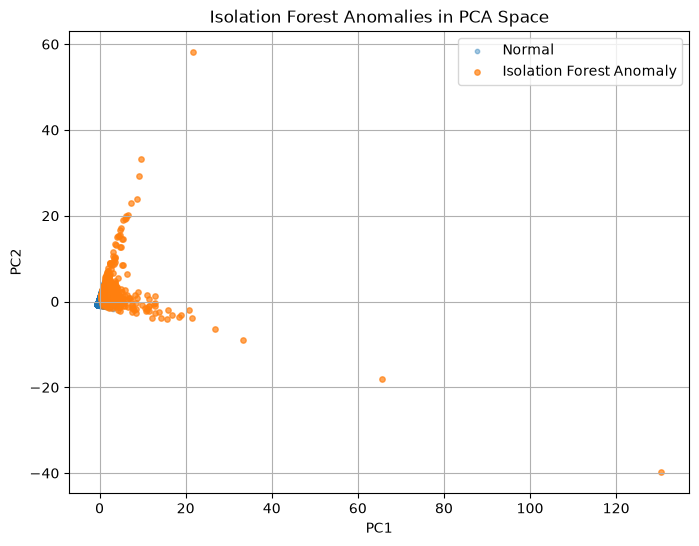

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[~df["iforest_anomaly"], 0],
    X_pca[~df["iforest_anomaly"], 1],
    s=10,
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    X_pca[df["iforest_anomaly"], 0],
    X_pca[df["iforest_anomaly"], 1],
    s=15,
    alpha=0.7,
    label="Isolation Forest Anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Anomalies in PCA Space")
plt.legend()
plt.grid(True)

plt.show()

The PCA visualization shows that Isolation Forest primarily identifies observations located away from the dense central region of the dataset.

Compared with the Z-score method, fewer observations are classified as anomalous, and the detected points are more concentrated in the extreme regions of the PCA projection.

This reflects the multidimensional nature of Isolation Forest, which evaluates unusual combinations of features rather than applying independent thresholds to each variable.

### 6.3 Local Outlier Factor (LOF)

Local Outlier Factor detects anomalies by comparing the local density of each observation with the density of its neighboring observations.

An observation is considered unusual when it lies in a region that is substantially less dense than the regions surrounding its neighbors.

Unlike global methods, LOF is designed to detect local anomalies. A point may therefore be considered anomalous even if it is not globally extreme, provided that it differs substantially from nearby observations.

The main parameter is `n_neighbors`, which controls the size of the local neighborhood used to estimate density.

In [66]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_labels = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_

df["lof_anomaly"] = lof_labels == -1
df["lof_score"] = lof_scores

print("LOF anomalies:", df["lof_anomaly"].sum())
print(
    "Percentage:",
    round(df["lof_anomaly"].mean() * 100, 2),
    "%"
)

LOF anomalies: 498
Percentage: 5.0 %


In [67]:
df[df["lof_anomaly"]][
    ["name", "lof_score"] + model_features
].sort_values(
    by="lof_score",
    ascending=False
).head(20)

,name,lof_score,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price_usd,initialprice_usd,discount,ccu,estimated_owners
5399,Weapons Genius,54.432441,549,640,0,0,0,0,0.99,0.99,0,1,350000.0
2540,RED TREES RAIL. CO.,51.809984,3,1,0,0,0,0,4.99,4.99,0,0,750000.0
2521,BeachHead Rogue,51.733355,12,1,0,0,0,0,4.99,4.99,0,1,750000.0
1579,Candle In Darkness,51.680818,6,2,0,0,0,0,4.99,4.99,0,0,750000.0
2861,Futon and Rocket Launcher,51.326388,20,0,0,0,0,0,3.99,3.99,0,0,350000.0
4846,Zone of Death,51.205270,3,3,0,0,0,0,3.99,3.99,0,0,350000.0
4745,我的变色龙女友My Chameleon Girlfriend,49.648377,10,7,0,0,0,0,3.99,3.99,0,0,350000.0
9938,Dungeonman,43.248569,0,1,0,0,0,0,2.99,2.99,0,0,75000.0
9701,My Dear Sister,43.248501,5,1,0,0,0,0,2.99,2.99,0,0,75000.0
9787,"Colossus Mission - adventure in space, arcade ...",43.132831,7,2,0,0,0,0,2.99,2.99,0,0,75000.0


The LOF method identifies 498 anomalies, corresponding to 5% of the dataset.

Unlike the Z-score and Isolation Forest results, the most extreme LOF observations are not dominated by the most globally popular games.

Instead, LOF highlights games that differ strongly from their local neighborhood in the multidimensional feature space. Many of the highest-scoring observations have relatively low player activity, review counts, and playtime, but unusual combinations of these variables compared with nearby games.

This demonstrates the local nature of LOF. An observation does not need to be globally extreme to be considered anomalous; it only needs to have a substantially lower local density than its neighbors.

Therefore, LOF may detect a different type of anomaly from methods that focus primarily on global extremeness.

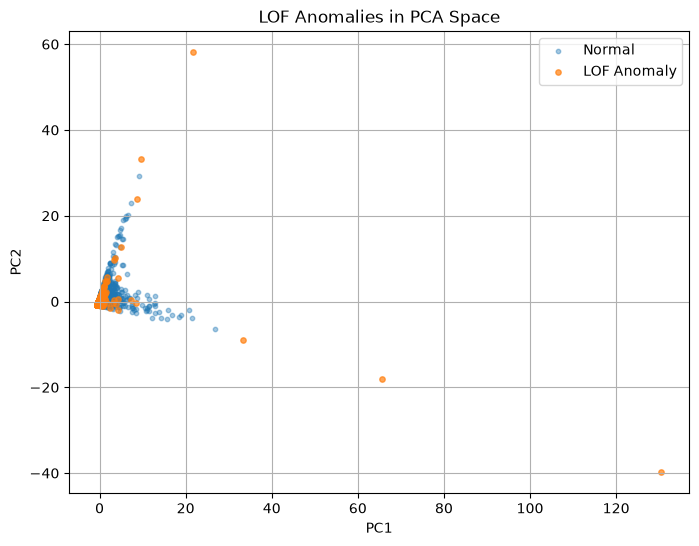

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[~df["lof_anomaly"], 0],
    X_pca[~df["lof_anomaly"], 1],
    s=10,
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    X_pca[df["lof_anomaly"], 0],
    X_pca[df["lof_anomaly"], 1],
    s=15,
    alpha=0.7,
    label="LOF Anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LOF Anomalies in PCA Space")
plt.legend()
plt.grid(True)

plt.show()

The PCA visualization shows that LOF detects a different anomaly pattern from the previous methods.

While some globally extreme observations are still identified, many LOF anomalies are located closer to the dense central region of the PCA projection.

This is consistent with the local-density principle of LOF. An observation may be classified as anomalous even when it is not globally distant, provided that its local neighborhood is substantially denser than the region in which the observation itself lies.

Therefore, LOF captures local irregularities that may not be detected by methods focused primarily on global extremeness.

### 6.4 LOF Sensitivity to Neighborhood Size

The behavior of LOF depends strongly on the `n_neighbors` parameter.

A small neighborhood emphasizes very local density differences, while a larger neighborhood compares observations using a broader region of the feature space.

To evaluate this sensitivity, LOF is repeated using several neighborhood sizes while keeping the contamination level fixed at 5%.

The detected anomaly sets are compared with the original `n_neighbors = 20` solution using Jaccard similarity.

In [69]:
from sklearn.metrics import jaccard_score

k_values = [5, 10, 20, 30, 50, 100]

baseline_lof = df["lof_anomaly"].to_numpy()

lof_k_results = []

for k in k_values:
    lof_test = LocalOutlierFactor(
        n_neighbors=k,
        contamination=0.05
    )

    test_labels = lof_test.fit_predict(X_scaled)
    test_anomalies = test_labels == -1

    lof_k_results.append({
        "n_neighbors": k,
        "Number of Anomalies": test_anomalies.sum(),
        "Jaccard Similarity vs k=20": jaccard_score(
            baseline_lof,
            test_anomalies
        )
    })

lof_k_sensitivity = pd.DataFrame(lof_k_results)

lof_k_sensitivity

,n_neighbors,Number of Anomalies,Jaccard Similarity vs k=20
0,5,498,0.225092
1,10,498,0.396914
2,20,498,1.000000
3,30,498,0.624796
4,50,498,0.300261
5,100,498,0.111607


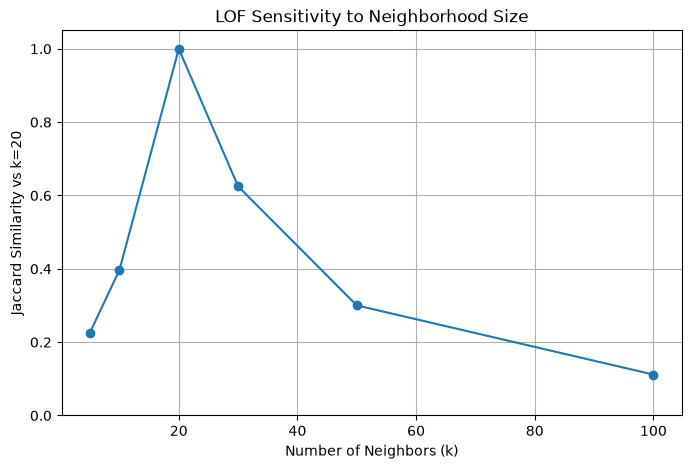

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    lof_k_sensitivity["n_neighbors"],
    lof_k_sensitivity["Jaccard Similarity vs k=20"],
    marker="o"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Jaccard Similarity vs k=20")
plt.title("LOF Sensitivity to Neighborhood Size")
plt.ylim(0, 1.05)
plt.grid(True)

plt.show()

The sensitivity analysis shows that the set of observations detected by LOF changes as the neighborhood size is modified.

Smaller values of `n_neighbors` emphasize highly local density differences and may identify points that differ only from a small number of nearby observations.

Larger values create a broader definition of the local neighborhood and may smooth over smaller local irregularities.

The changing Jaccard similarity demonstrates that LOF is sensitive to the choice of \(k\). Therefore, the anomaly set produced by LOF should not be interpreted as a parameter-independent ground truth.

The value `n_neighbors = 20` is retained as a reasonable intermediate neighborhood size, while the sensitivity analysis demonstrates the uncertainty associated with this methodological choice.

## 7. Comparison of Anomaly Detection Methods

The three anomaly detection methods are now compared to determine where their results agree and where they differ.

Because each method defines abnormality differently, disagreement between the methods is expected and can provide insight into different types of unusual observations.

In [71]:
comparison = pd.DataFrame({
    "Z-Score": df["zscore_anomaly"],
    "Isolation Forest": df["iforest_anomaly"],
    "LOF": df["lof_anomaly"]
})

comparison.sum()

Z-Score             979
Isolation Forest    498
LOF                 498
dtype: int64

In [72]:
all_three = (
    comparison["Z-Score"] &
    comparison["Isolation Forest"] &
    comparison["LOF"]
).sum()

z_if = (
    comparison["Z-Score"] &
    comparison["Isolation Forest"]
).sum()

z_lof = (
    comparison["Z-Score"] &
    comparison["LOF"]
).sum()

if_lof = (
    comparison["Isolation Forest"] &
    comparison["LOF"]
).sum()

print("Detected by all three methods:", all_three)
print("Z-Score and Isolation Forest:", z_if)
print("Z-Score and LOF:", z_lof)
print("Isolation Forest and LOF:", if_lof)

Detected by all three methods: 23
Z-Score and Isolation Forest: 347
Z-Score and LOF: 44
Isolation Forest and LOF: 28


The comparison reveals substantial disagreement between the three anomaly detection methods.

The Z-score method identifies 979 anomalies, while Isolation Forest and LOF each identify 498 observations due to the selected contamination level.

Only 23 observations are identified as anomalous by all three methods.

The strongest agreement occurs between Z-score and Isolation Forest, with 347 shared detections. In contrast, the overlap involving LOF is much smaller: only 44 observations are shared between Z-score and LOF, and 28 between Isolation Forest and LOF.

This difference reflects the underlying definitions of abnormality used by each method. Z-score and Isolation Forest tend to emphasize globally extreme observations, whereas LOF focuses on observations that are unusual relative to their local neighborhood.

Therefore, disagreement between the methods should not necessarily be interpreted as a failure. Instead, each method captures a different aspect of anomalous behavior in the dataset.

In [73]:
z_only = (
    comparison["Z-Score"] &
    ~comparison["Isolation Forest"] &
    ~comparison["LOF"]
).sum()

if_only = (
    ~comparison["Z-Score"] &
    comparison["Isolation Forest"] &
    ~comparison["LOF"]
).sum()

lof_only = (
    ~comparison["Z-Score"] &
    ~comparison["Isolation Forest"] &
    comparison["LOF"]
).sum()

print("Z-Score only:", z_only)
print("Isolation Forest only:", if_only)
print("LOF only:", lof_only)

Z-Score only: 611
Isolation Forest only: 146
LOF only: 449


In [74]:
df["anomaly_method_count"] = comparison.sum(axis=1)

df["anomaly_method_count"].value_counts().sort_index()

anomaly_method_count
0    8378
1    1206
2     350
3      23
Name: count, dtype: int64

The agreement analysis shows that most observations are not considered anomalous by any method.

Out of 9,957 games, 8,378 are classified as normal by all three methods.

A total of 1,206 games are identified as anomalous by only one method, while 350 are identified by two methods.

Only 23 observations are classified as anomalous by all three methods.

The large number of method-specific detections demonstrates that anomaly detection is highly dependent on the mathematical definition of abnormality. Different methods emphasize different structures in the data, such as global extremeness, multidimensional isolation, or local density.

Observations detected by all three methods can be considered particularly strong anomaly candidates, although they should still be interpreted in the real-world context of the dataset rather than automatically treated as errors.

The largest number of method-specific anomalies comes from the Z-score method, which uniquely identifies 611 observations. This is consistent with its sensitivity to the strongly skewed feature distributions.

Isolation Forest uniquely identifies 146 observations, while LOF uniquely identifies 449 observations.

The large number of LOF-specific detections reinforces the observation that LOF captures local irregularities that are often not globally extreme.

In [75]:
all_methods_anomalies = df[
    df["anomaly_method_count"] == 3
][
    [
        "name",
        "positive",
        "negative",
        "average_forever",
        "average_2weeks",
        "median_forever",
        "median_2weeks",
        "price_usd",
        "initialprice_usd",
        "discount",
        "ccu",
        "estimated_owners"
    ]
]

all_methods_anomalies

,name,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price_usd,initialprice_usd,discount,ccu,estimated_owners
0,Counter-Strike: Global Offensive,7642084,1173003,34112,731,6777,297,0.00,0.00,0,1013936,150000000.0
1,Apex Legends,668053,326926,11025,635,977,256,0.00,0.00,0,124262,150000000.0
2,PUBG: BATTLEGROUNDS,1520457,1037487,23333,820,5899,335,0.00,0.00,0,314682,150000000.0
58,Battlefield 2042,139186,158588,3046,136,982,58,59.99,59.99,0,2774,15000000.0
77,Z1 Battle Royale,113729,90284,3343,0,208,0,0.00,0.00,0,1010,15000000.0
99,EA SPORTS FIFA 23,86192,65227,9986,100,5503,133,0.00,0.00,0,1280,7500000.0
208,Grand Theft Auto V Enhanced,38595,17286,1561,442,268,139,19.79,44.99,56,39502,7500000.0
439,鬼谷八荒 Tale of Immortal,121020,106084,4135,597,2237,887,19.99,19.99,0,4116,3500000.0
479,ELDEN RING NIGHTREIGN,48901,16771,3836,750,2305,309,39.99,39.99,0,163599,3500000.0
1133,Football Manager 2024,20927,2121,22317,1355,14444,574,59.99,59.99,0,47931,1500000.0


The 23 observations detected by all three methods represent the strongest anomaly candidates in the dataset.

However, these observations do not all share the same type of abnormality.

Some games, such as Counter-Strike: Global Offensive, Apex Legends, and PUBG: BATTLEGROUNDS, are anomalous primarily because of their exceptionally large popularity, ownership, review, and concurrent-player values.

Other observations are characterized by extremely unusual playtime patterns. Games or applications such as Terminal Hacker, YoloMouse - Game Cursor Changer, and Wizard And Minion Idle have exceptionally large long-term playtime values despite relatively low current activity or popularity.

This demonstrates that multidimensional anomalies may arise from different combinations of features rather than from a single extreme variable.

The agreement of all three methods increases confidence that these observations are statistically unusual. Nevertheless, they should not automatically be interpreted as errors. Some may represent genuinely exceptional games, idle-game behavior, software running for long periods, or characteristics of how SteamSpy measures player activity.

### 7.1 Method-Specific Anomalies

The observations detected exclusively by each anomaly detection method are examined to understand how the mathematical assumptions of the methods influence their results.

In [76]:
z_only_mask = (
    df["zscore_anomaly"] &
    ~df["iforest_anomaly"] &
    ~df["lof_anomaly"]
)

if_only_mask = (
    ~df["zscore_anomaly"] &
    df["iforest_anomaly"] &
    ~df["lof_anomaly"]
)

lof_only_mask = (
    ~df["zscore_anomaly"] &
    ~df["iforest_anomaly"] &
    df["lof_anomaly"]
)

In [77]:
print("Examples detected only by Z-Score:")
display(
    df[z_only_mask][
        ["name", "positive", "negative", "average_forever",
         "average_2weeks", "ccu", "estimated_owners"]
    ].head(10)
)

print("Examples detected only by Isolation Forest:")
display(
    df[if_only_mask][
        ["name", "positive", "negative", "average_forever",
         "average_2weeks", "ccu", "estimated_owners"]
    ].head(10)
)

print("Examples detected only by LOF:")
display(
    df[lof_only_mask][
        ["name", "positive", "negative", "average_forever",
         "average_2weeks", "ccu", "estimated_owners"]
    ].head(10)
)

Examples detected only by Z-Score:


,name,positive,negative,average_forever,average_2weeks,ccu,estimated_owners
30,War Robots: Frontiers,1977,1105,484,0,256,35000000.0
36,Half-Life 2: Lost Coast,12215,1471,0,0,2,35000000.0
50,Half-Life 2: Deathmatch,12962,1334,1957,27,159,15000000.0
51,Half-Life,143086,5135,729,90,634,15000000.0
67,Portal,175024,2717,338,66,638,15000000.0
69,Black Squad,62042,19672,1568,16,212,15000000.0
74,Counter-Strike: Condition Zero,13442,1535,376,182,83,15000000.0
76,Street Warriors Online,941,693,74,0,1,15000000.0
80,CyberCorp,266,56,13,0,3,15000000.0
91,Life is Strange 2,31616,5018,440,1,153,15000000.0


Examples detected only by Isolation Forest:


,name,positive,negative,average_forever,average_2weeks,ccu,estimated_owners
97,NBA 2K20,30260,30413,6412,0,221,7500000.0
98,Risk of Rain 2,293127,20450,3443,251,7902,7500000.0
101,PlanetSide 2,59598,14096,2395,976,496,7500000.0
106,MONSTER HUNTER RISE,92564,20108,4911,275,3658,7500000.0
111,Robocraft,86240,31815,1397,0,3,7500000.0
113,Resident Evil 4,177539,4169,2249,529,3748,7500000.0
122,Content Warning,137483,7608,322,68,722,7500000.0
128,SCP: Secret Laboratory,195923,18386,1593,376,4696,7500000.0
132,Dota Underlords,74753,16141,3023,138,1008,7500000.0
133,It Takes Two,208042,10341,1706,211,5018,7500000.0


Examples detected only by LOF:


,name,positive,negative,average_forever,average_2weeks,ccu,estimated_owners
200,Call of Duty: Modern Warfare 2 (2009),31945,2927,7468,17,190,7500000.0
365,Company of Heroes - Legacy Edition,6540,457,455,0,65,3500000.0
424,The Day Before,3686,19751,0,0,0,3500000.0
437,DEVOUR,75057,7457,454,119,447,3500000.0
553,The Red Solstice,1772,729,342,0,5,3500000.0
659,ROUNDS,34893,1765,747,192,555,3500000.0
759,Wolcen: Lords of Mayhem,37846,29831,1925,0,30,1500000.0
1016,小黑盒加速器,7088,1800,0,0,3328,1500000.0
1057,Just Survive,45716,31640,3504,0,1,1500000.0
1463,ABZU,24253,1860,160,0,10,750000.0


The method-specific examples illustrate the different definitions of abnormality used by the three algorithms.

The Z-score method identifies observations when one or more individual features deviate strongly from their global mean. As a result, some games may be classified as anomalous even when their overall multidimensional profile is not strongly isolated.

Isolation Forest identifies unusual combinations of features. Several games detected only by this method have moderately large values across multiple variables rather than one exceptionally extreme feature. Their joint feature profiles make them easier to isolate through random partitioning.

LOF produces a substantially different set of method-specific anomalies. These games are not necessarily globally extreme, but their feature combinations differ from those of their nearest neighbors. This reflects LOF's emphasis on local density rather than global distance or individual feature thresholds.

The disagreement between the methods therefore reflects differences in what each algorithm considers unusual rather than an inconsistency in the analysis.

### 7.2 Sensitivity to Feature Scaling

Feature scaling affects anomaly detection methods differently.

The Z-score method inherently standardizes each feature relative to its own mean and standard deviation. Therefore, linear changes in measurement units have little effect on the resulting standardized scores.

LOF is substantially more sensitive to feature scaling because it relies on distances between observations. Without standardization, features with large numerical ranges, such as `estimated_owners`, could dominate the neighborhood calculations.

Isolation Forest is generally less sensitive to differences in feature scale because it isolates observations using random feature splits rather than direct distance calculations. Nevertheless, standardized features were used consistently throughout this analysis to provide a common numerical representation across methods.

Standardization is therefore particularly important for distance-based approaches and also improves methodological consistency when comparing the three techniques.

### 7.3 Sensitivity to Dimensionality

Increasing dimensionality can make anomaly detection more difficult because observations become increasingly sparse and distance relationships become less informative.

This issue is particularly relevant to LOF, which relies directly on local neighborhoods and distance comparisons. As dimensionality increases, the distinction between near and distant observations may become less meaningful.

The Z-score method evaluates features individually and is therefore less directly affected by geometric distance. However, adding more features increases the probability that an observation exceeds the anomaly threshold in at least one dimension.

Isolation Forest is generally more suitable for moderately high-dimensional data because it does not rely directly on pairwise distances. However, irrelevant or redundant variables may still influence the random partitioning process.

The PCA analysis showed that five principal components preserve more than 90% of the variance contained in the original 11 numerical features. This confirms that the feature space contains substantial redundancy and suggests that dimensionality reduction could provide a more compact representation of the data.

### 7.4 Runtime and Scalability

The computational runtime of the three anomaly detection methods is measured on the same standardized dataset.

Runtime is only one aspect of scalability, but it provides a practical indication of how efficiently each method operates on the current dataset.

In [78]:
import time

runtime_results = {}

start = time.perf_counter()
_ = (np.abs(X_scaled) > 3).any(axis=1)
runtime_results["Z-Score"] = time.perf_counter() - start

start = time.perf_counter()
_ = IsolationForest(
    contamination=0.05,
    random_state=42
).fit_predict(X_scaled)
runtime_results["Isolation Forest"] = time.perf_counter() - start

start = time.perf_counter()
_ = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
).fit_predict(X_scaled)
runtime_results["LOF"] = time.perf_counter() - start

runtime_df = pd.DataFrame(
    runtime_results.items(),
    columns=["Method", "Runtime (seconds)"]
)

runtime_df

,Method,Runtime (seconds)
0,Z-Score,0.000822
1,Isolation Forest,0.152539
2,LOF,0.304930


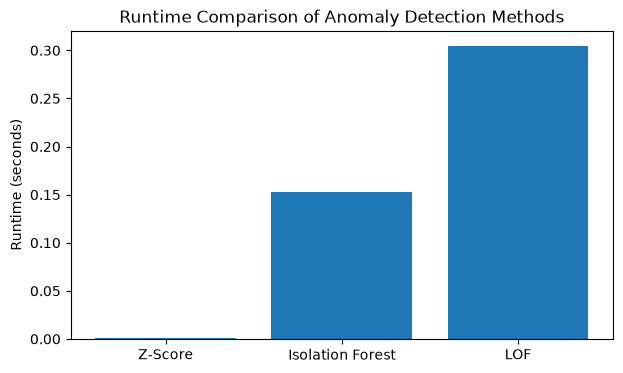

In [79]:
plt.figure(figsize=(7, 4))

plt.bar(
    runtime_df["Method"],
    runtime_df["Runtime (seconds)"]
)

plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison of Anomaly Detection Methods")

plt.show()

The runtime comparison shows clear computational differences between the three methods.

The Z-score method is by far the fastest because it requires only simple feature-wise arithmetic operations.

Isolation Forest requires more computation because it constructs an ensemble of random isolation trees, but its runtime remains relatively low for the current dataset.

LOF is the slowest method in this experiment because it relies on neighborhood and distance calculations between observations.

These measurements were obtained on the current dataset and computing environment, so the exact values may vary on different hardware or between executions. However, the relative behavior is consistent with the computational characteristics of the methods.

From a scalability perspective, the Z-score method is computationally inexpensive, Isolation Forest provides a practical compromise between computational cost and multidimensional anomaly detection, while LOF may become more demanding as the number of observations and dimensions increases.

### 7.5 Robustness to Noise

To evaluate the robustness of the anomaly detection methods, small amounts of Gaussian noise are added to the standardized feature matrix.

Three noise levels are examined: 0.01, 0.05, and 0.10 standard deviations.

Each anomaly detection method is then applied again using the same parameters as in the original analysis.

The stability of each method is measured using the Jaccard similarity between the original anomaly set and the anomaly set obtained after adding noise.

A Jaccard similarity close to 1 indicates that the detected anomalies remain highly stable, while a lower value indicates greater sensitivity to small perturbations in the data.

In [80]:
from sklearn.metrics import jaccard_score

# Test anomaly-set stability under controlled Gaussian perturbations
noise_levels = [0.01, 0.05, 0.10]
rng = np.random.default_rng(42)

noise_results = []

original_z = df["zscore_anomaly"].to_numpy()
original_if = df["iforest_anomaly"].to_numpy()
original_lof = df["lof_anomaly"].to_numpy()

for noise_level in noise_levels:
    noise = rng.normal(
        loc=0,
        scale=noise_level,
        size=X_scaled.shape
    )

    X_noisy = X_scaled.to_numpy() + noise

    X_noisy = StandardScaler().fit_transform(X_noisy)

    noisy_z = (np.abs(X_noisy) > 3).any(axis=1)

    noisy_if = IsolationForest(
        contamination=0.05,
        random_state=42
    ).fit_predict(X_noisy) == -1

    noisy_lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.05
    ).fit_predict(X_noisy) == -1

    noise_results.append({
        "Noise Level": noise_level,
        "Z-Score": jaccard_score(original_z, noisy_z),
        "Isolation Forest": jaccard_score(original_if, noisy_if),
        "LOF": jaccard_score(original_lof, noisy_lof)
    })

noise_stability = pd.DataFrame(noise_results)

noise_stability

,Noise Level,Z-Score,Isolation Forest,LOF
0,0.01,1.000000,0.926499,0.217604
1,0.05,0.987792,0.851301,0.109131
2,0.10,0.962777,0.801085,0.079090


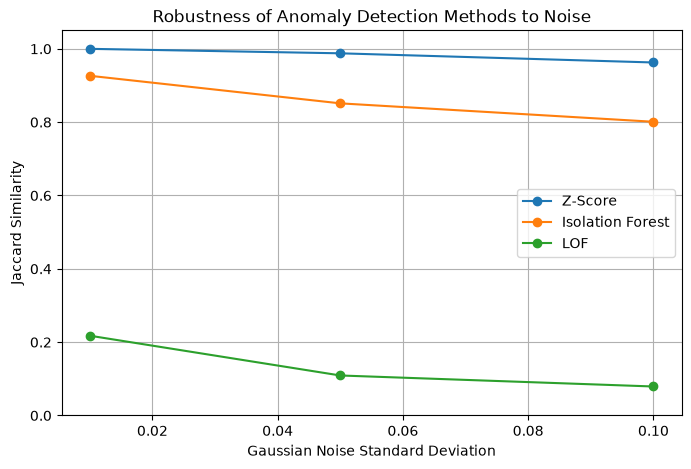

In [81]:
plt.figure(figsize=(8, 5))

for method in ["Z-Score", "Isolation Forest", "LOF"]:
    plt.plot(
        noise_stability["Noise Level"],
        noise_stability[method],
        marker="o",
        label=method
    )

plt.xlabel("Gaussian Noise Standard Deviation")
plt.ylabel("Jaccard Similarity")
plt.title("Robustness of Anomaly Detection Methods to Noise")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)

plt.show()

The noise robustness experiment reveals substantial differences between the three anomaly detection methods.

The Z-score method is highly stable under the tested perturbations. Its Jaccard similarity remains approximately 1.00 for very small noise and above 0.96 even when the noise standard deviation reaches 0.10.

Isolation Forest also demonstrates relatively strong robustness, although its stability decreases gradually as the amount of noise increases. The Jaccard similarity decreases from approximately 0.93 to 0.80 across the tested noise levels.

LOF is substantially more sensitive to noise. Even at a noise standard deviation of 0.01, the overlap with the original anomaly set falls to approximately 0.22, and it decreases further as noise increases.

This behavior is consistent with the local-density nature of LOF. Small perturbations can change nearest-neighbor relationships and local density estimates, resulting in substantial changes in which observations are classified as anomalies.

Overall, Z-score is the most stable method under small perturbations in this experiment, followed by Isolation Forest, while LOF shows considerably lower robustness to noise.

### 7.6 Interpretability

The three anomaly detection methods also differ substantially in how easily their results can be interpreted.

The Z-score method provides the most direct interpretation. A game can be identified as anomalous because a specific feature exceeds a defined number of standard deviations from the feature mean. This makes it relatively easy to explain which variables caused the anomaly classification.

Isolation Forest provides an anomaly score and evaluates observations using their multidimensional feature combinations. However, explaining exactly which features caused a particular observation to be isolated is less straightforward than with the Z-score method.

LOF provides an interpretation based on local density. A high LOF score indicates that an observation lies in a region of lower density than its neighboring observations. Although this provides a meaningful conceptual explanation, identifying the exact variables responsible for the local abnormality can be difficult in a high-dimensional feature space.

Therefore, Z-score provides the highest direct interpretability, while Isolation Forest and LOF provide more flexible multidimensional definitions of abnormality at the cost of less transparent individual explanations.

### 7.7 False Positives and False Negatives

Because the dataset does not contain ground-truth anomaly labels, false positives and false negatives cannot be measured directly.

However, their practical meaning can still be discussed in the context of Steam games.

A false positive would occur when a legitimate game is classified as anomalous even though its unusual values are valid. For example, a highly successful game with exceptionally large review counts, ownership, or concurrent player activity may be flagged simply because it is much more popular than most other games.

A false negative would occur when a genuinely unusual or problematic observation is classified as normal. For example, a game with an unusual combination of playtime, activity, ownership, and pricing values could remain inside the normal region if the anomaly detection method is not sensitive to that particular pattern.

The consequences of these errors depend on the purpose of the analysis. If anomaly detection were used for data-quality monitoring, false positives could create unnecessary manual investigations, while false negatives could allow corrupted or suspicious records to remain undetected.

In this dataset, the distinction between an error and a legitimate anomaly is particularly important because many statistically extreme observations correspond to real and highly successful games rather than incorrect data.

## 8. Critical Analysis and Reflection

### 8.1 Why Anomaly Detection Is Ill-Defined

Anomaly detection is fundamentally difficult because there is no universal definition of what should be considered abnormal.

In this dataset, an observation may appear statistically extreme while still representing a completely legitimate Steam game. For example, very popular games can have review counts, ownership estimates, or concurrent-player activity that are far larger than those of most other games.

The results of this analysis demonstrate this ambiguity clearly. Z-score, Isolation Forest, and LOF identified substantially different sets of anomalies, and only 23 games were detected by all three methods.

This disagreement does not necessarily mean that one method is incorrect. Instead, each algorithm defines abnormality differently. Z-score emphasizes deviations in individual features, Isolation Forest focuses on observations that are easy to isolate in the multidimensional feature space, and LOF focuses on differences in local density.

Therefore, anomaly detection should be interpreted as a context-dependent analytical process rather than as a method that produces a single objectively correct answer.

### 8.2 Curse of Dimensionality

As the number of dimensions increases, the feature space becomes increasingly sparse. This phenomenon is known as the curse of dimensionality.

In high-dimensional spaces, observations tend to become more uniformly distant from one another, reducing the distinction between nearby and distant points.

This can make distance-based methods less reliable because neighborhood relationships become less informative.

LOF is particularly sensitive to this issue because its anomaly score depends directly on the local density and nearest neighbors of each observation.

The PCA analysis showed that the original 11 numerical features could be represented using five principal components while preserving more than 90% of the total variance. This indicates that the dataset contains substantial redundancy and that dimensionality reduction may help reduce some of the difficulties associated with high-dimensional analysis.

### 8.3 Noise vs. Genuine Anomalies

A genuine anomaly is an unusual but meaningful observation, while noise may result from measurement errors, data-entry problems, incomplete information, or limitations of the data collection process.

The distinction is not always clear.

For example, Counter-Strike: Global Offensive appears as an extreme observation across multiple analyses because of its exceptionally large ownership, review, and concurrent-player values. These values are unusual, but they are plausible for an extremely popular game and therefore represent a legitimate anomaly rather than obvious noise.

Other observations with exceptionally high reported playtime are more ambiguous. Games or applications such as Terminal Hacker or YoloMouse may reflect idle behavior, software running for extended periods, or characteristics of the SteamSpy measurement process.

Without independent ground-truth information, these cases cannot be classified confidently as either errors or genuine unusual behavior.

### 8.4 Risks of Assuming Gaussian Distributions

Assuming that the data follow Gaussian distributions can lead to misleading anomaly classifications.

The exploratory analysis showed that many features in this dataset are strongly right-skewed and heavy-tailed. Review counts, player activity, ownership, and playtime are particularly far from normally distributed.

Under a Gaussian assumption, large deviations from the mean may appear extremely unlikely. However, in heavy-tailed distributions, very large values can occur naturally.

This explains why the Z-score method classified approximately 9.83% of the dataset as anomalous. Many of these observations represent legitimate popular or highly active games rather than obvious errors.

As a result, Gaussian-based thresholds may produce false positives in this dataset and may fail to accurately represent the true probability of extreme observations.

Gaussian feature-wise thresholds may also produce false negatives. A game may have a genuinely unusual multidimensional combination of several moderately unusual feature values without any single feature exceeding the Z-score threshold. Such an observation could therefore remain classified as normal even though its overall profile is unusual.

### 8.5 Limitations of PCA Visualizations

Low-dimensional PCA visualizations provide a useful summary of the dataset, but they can also be misleading.

The two-dimensional PCA projection used only the first two principal components, which preserved approximately 51.7% of the total variance. The three-dimensional projection preserved approximately 68.5%.

Therefore, a substantial amount of information from the original 11-dimensional feature space is not visible in these plots.

Two observations that appear close together in a 2D PCA visualization may still differ significantly along components that are not displayed. Similarly, an observation that does not appear visually isolated may still be anomalous in the full-dimensional feature space.

For this reason, PCA visualizations are useful for interpretation but should not be treated as definitive evidence of cluster structure or anomaly status.

### 8.6 Ethical Considerations

Anomaly detection can be useful in many real-world applications, but incorrect classifications may have significant consequences.

In systems that generate frequent false alarms, users may begin to ignore alerts. This can reduce the effectiveness of the anomaly detection system and increase the risk that a genuinely important event will be missed.

In surveillance applications, anomaly detection may help identify unusual or potentially dangerous behavior. However, such systems can also raise concerns related to privacy, bias, and unfair labeling of individuals whose behavior differs from the statistical norm.

In medical applications, false positives may cause unnecessary stress, additional testing, and medical intervention, while false negatives may delay the identification of serious health conditions.

In cybersecurity, failing to detect a genuine attack may result in data loss, service disruption, or unauthorized access. On the other hand, incorrectly classifying legitimate activity as malicious can interrupt normal operations and create excessive investigation workload.

More generally, anomaly detection systems should not automatically equate unusual behavior with harmful or incorrect behavior. Statistical abnormality depends on the data, the selected features, the detection method, and the threshold used.

In the context of this Steam dataset, highly popular or highly played games may be statistically unusual without being problematic. This illustrates why anomaly detection results should always be interpreted with appropriate domain knowledge and should not be used as automatic judgments without further investigation.

### 8.7 Critical Reflection Summary

The analysis demonstrates that unsupervised anomaly detection does not produce a single objectively correct answer.

Different algorithms identify different forms of abnormality, and their results depend on assumptions about distributions, distance, density, dimensionality, and parameter selection.

For the Steam dataset, extreme observations often represent legitimate but unusual games rather than data errors. The strong disagreement between Z-score, Isolation Forest, and LOF reinforces the importance of combining quantitative methods with real-world interpretation.

Dimensionality reduction and visualization can support the analysis, but they also remove information and should therefore be interpreted cautiously.

Overall, the results show that anomaly detection is best treated as a tool for identifying observations that deserve further investigation rather than as an automatic mechanism for declaring observations correct or incorrect.

## 9. Final Conclusion

This analysis explored the structure of a real-world Steam games dataset using exploratory analysis, dimensionality reduction, clustering, and multiple anomaly detection methods.

The exploratory analysis showed that many numerical features are strongly right-skewed and heavy-tailed. Review counts, ownership estimates, concurrent player activity, and playtime contain extreme values that often represent legitimate but uncommon games rather than obvious data errors.

PCA revealed substantial redundancy in the original feature space. Five principal components preserved more than 90% of the total variance, while the component loadings showed meaningful groups related to popularity, player engagement, pricing, and discount behavior.

The clustering analysis did not reveal a clear and balanced natural partition of Steam games. K-Means and hierarchical clustering were strongly influenced by extreme observations, while DBSCAN identified one dominant dense region together with a relatively small number of isolated observations. Feature-space clustering was more informative and revealed clear relationships between popularity, pricing, and engagement variables.

The anomaly detection methods produced substantially different results. Z-score identified 979 anomalies, while Isolation Forest and LOF each identified 498 observations under the selected contamination level. Only 23 games were detected by all three methods.

Z-score was highly interpretable and computationally inexpensive, but its Gaussian assumptions were poorly matched to the strongly skewed distributions in the dataset. Isolation Forest provided a more flexible multidimensional approach and showed relatively strong robustness to noise. LOF identified a substantially different set of local anomalies, but it was more sensitive to noise and neighborhood structure.

Overall, no single method can be considered universally correct for this dataset. The results demonstrate that unusual observations can arise from very different causes, including exceptional popularity, unusual playtime behavior, pricing patterns, or local differences in feature density.

Therefore, anomaly detection should be treated as a method for identifying observations that require further investigation rather than as an automatic procedure for labeling data as correct or incorrect.

The most reliable interpretation is obtained by combining multiple methods, examining their agreement and disagreement, and relating the mathematical results to the real-world meaning of the Steam game data.

## 10. Final Visualization Dashboard

This optional section summarizes the main findings of the analysis using compact visualizations.

The dashboard includes dimensionality reduction, clustering, anomaly detection, pairwise feature relationships, and correlation structure in order to provide a concise visual overview of the dataset.

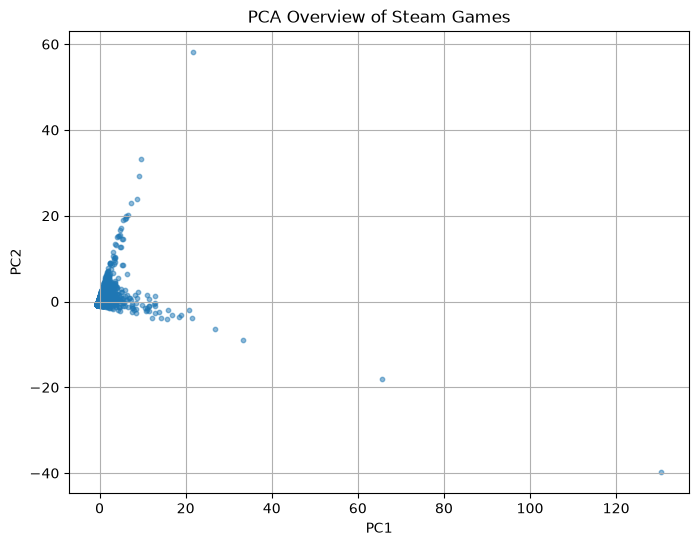

In [82]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Overview of Steam Games")
plt.grid(True)

plt.show()

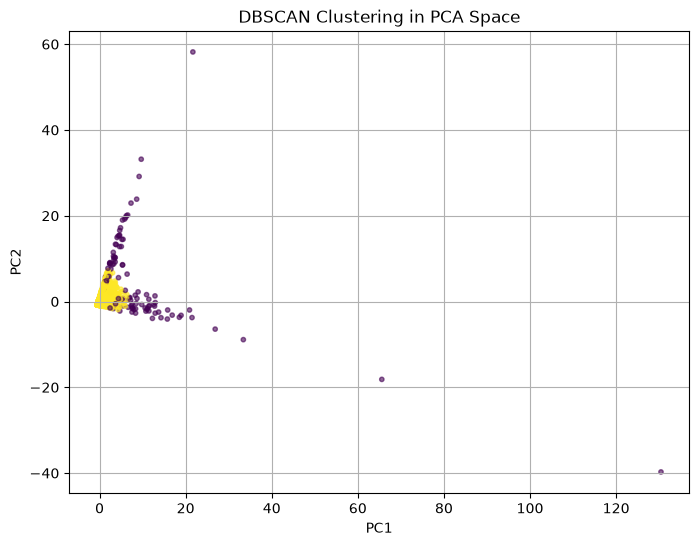

In [83]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["dbscan_cluster"],
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering in PCA Space")
plt.grid(True)

plt.show()

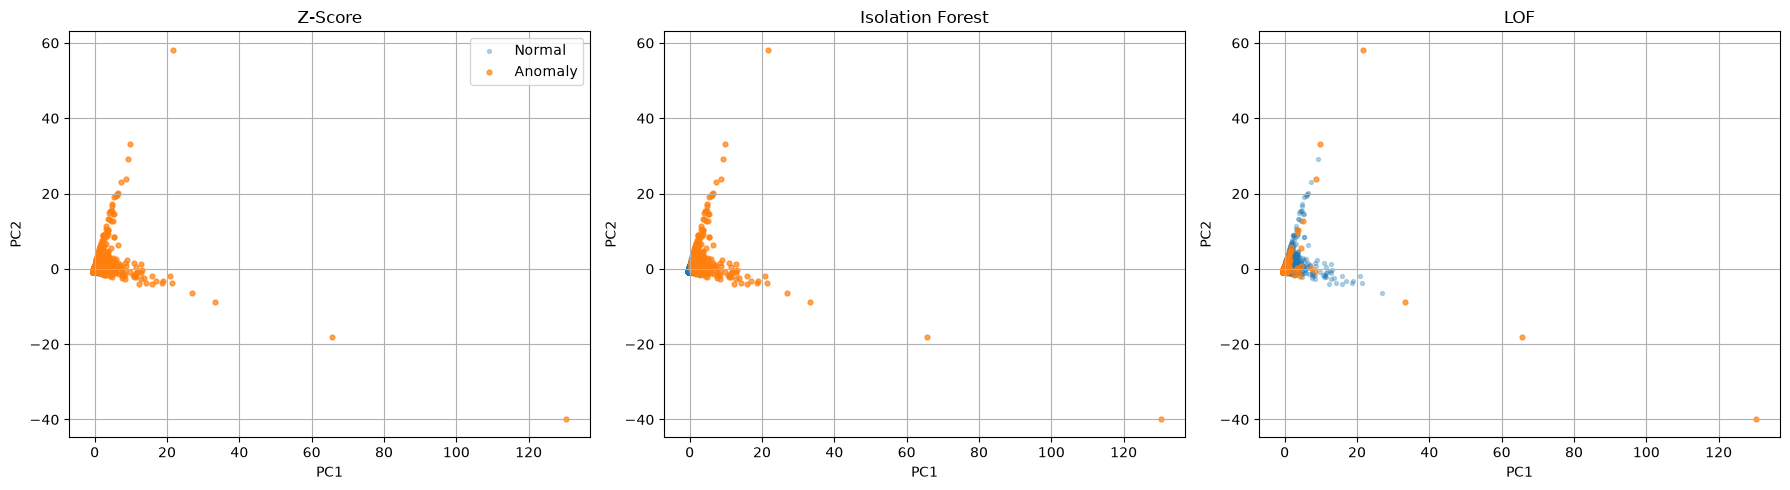

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ("zscore_anomaly", "Z-Score"),
    ("iforest_anomaly", "Isolation Forest"),
    ("lof_anomaly", "LOF")
]

for ax, (column, title) in zip(axes, methods):
    normal = ~df[column]
    anomaly = df[column]

    ax.scatter(
        X_pca[normal, 0],
        X_pca[normal, 1],
        s=8,
        alpha=0.3,
        label="Normal"
    )

    ax.scatter(
        X_pca[anomaly, 0],
        X_pca[anomaly, 1],
        s=12,
        alpha=0.7,
        label="Anomaly"
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(True)

axes[0].legend()

plt.tight_layout()
plt.show()

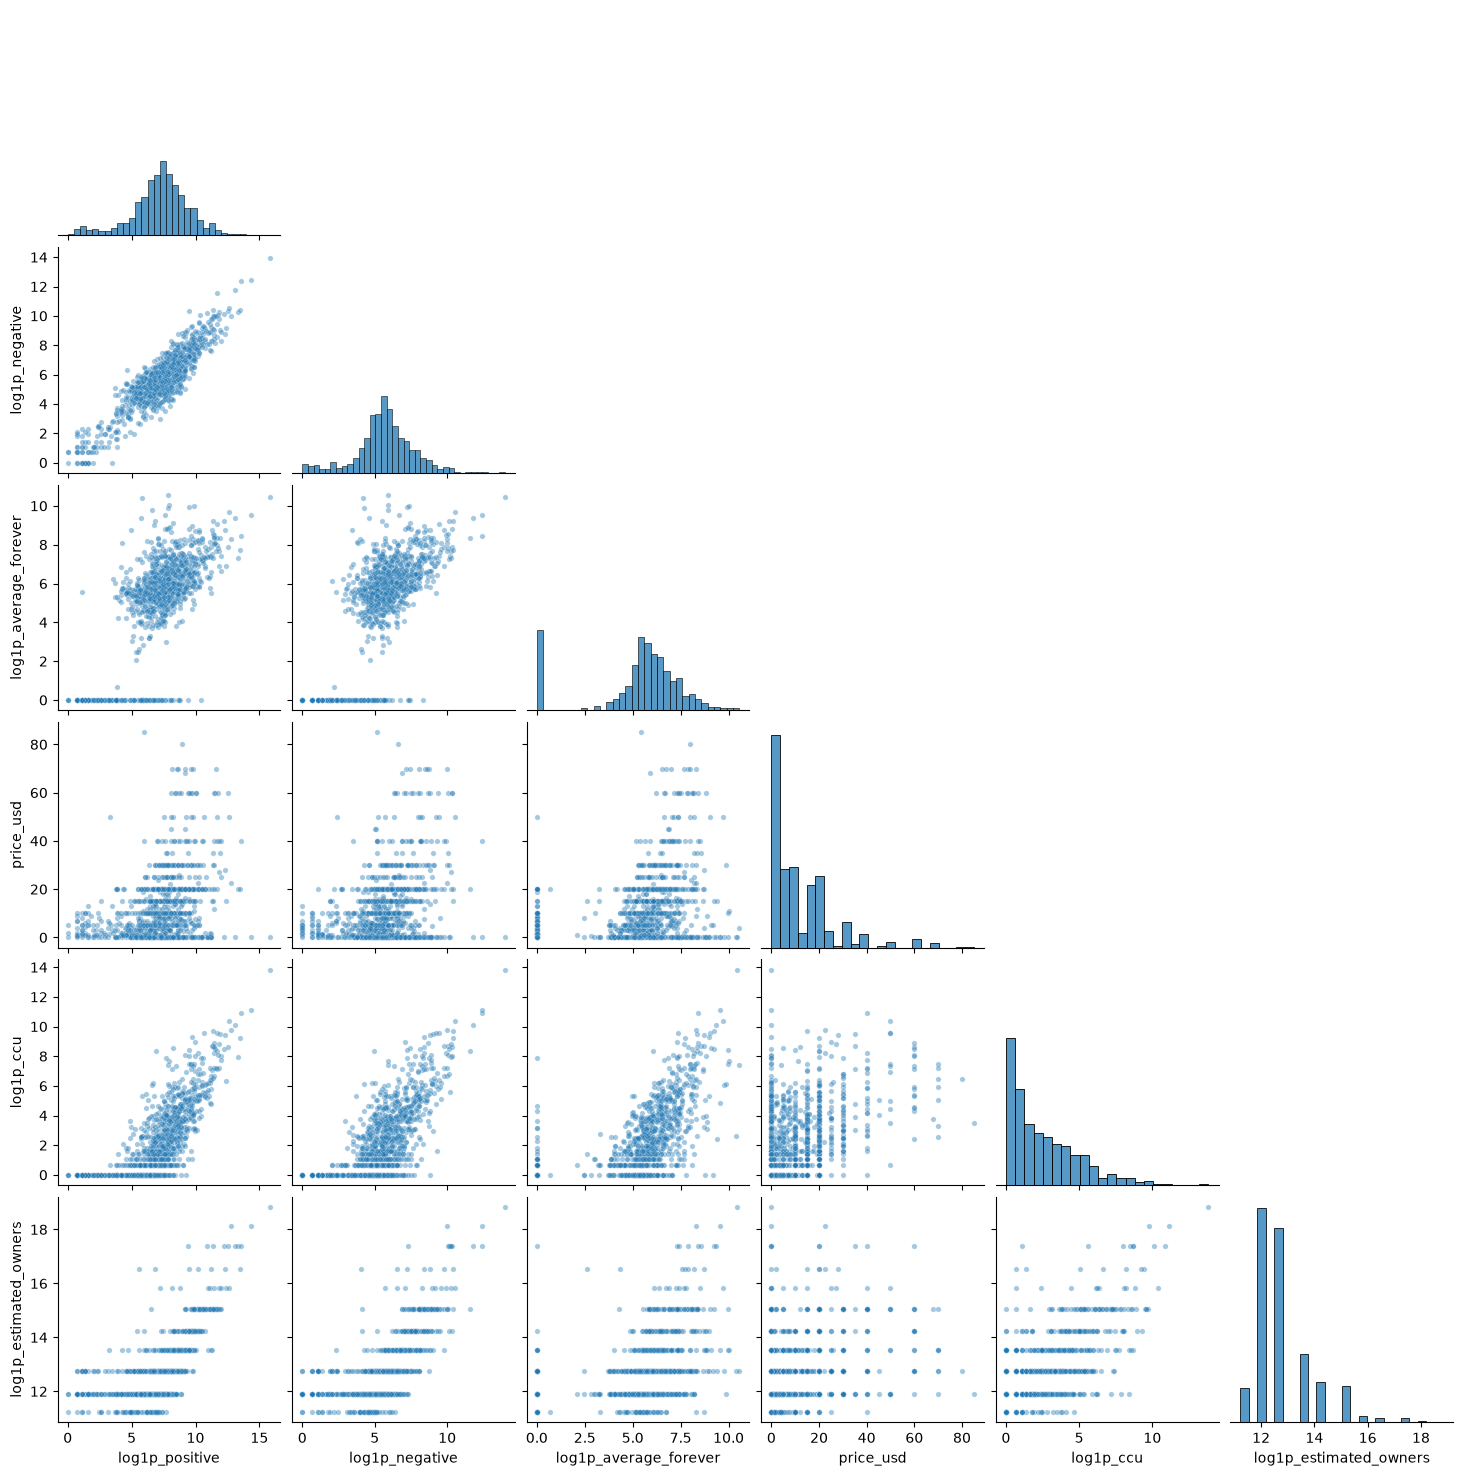

In [85]:
import seaborn as sns

pairplot_features = [
    "positive",
    "negative",
    "average_forever",
    "price_usd",
    "ccu",
    "estimated_owners"
]

pairplot_sample = df[pairplot_features].sample(
    n=1000,
    random_state=42
).copy()

log_features = [
    "positive",
    "negative",
    "average_forever",
    "ccu",
    "estimated_owners"
]

pairplot_sample[log_features] = np.log1p(
    pairplot_sample[log_features]
)

pairplot_sample = pairplot_sample.rename(columns={
    "positive": "log1p_positive",
    "negative": "log1p_negative",
    "average_forever": "log1p_average_forever",
    "ccu": "log1p_ccu",
    "estimated_owners": "log1p_estimated_owners"
})

sns.pairplot(
    pairplot_sample,
    corner=True,
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.show()

Because several Steam activity and popularity features are extremely right-skewed, logarithmic transformation is used in the pairplot to improve visual readability.

The transformation compresses extreme values while preserving the ordering of observations, making relationships among reviews, ownership, playtime, and concurrent activity easier to examine.

`price_usd` is retained on its original scale because its numerical range is substantially smaller than the activity-related variables.

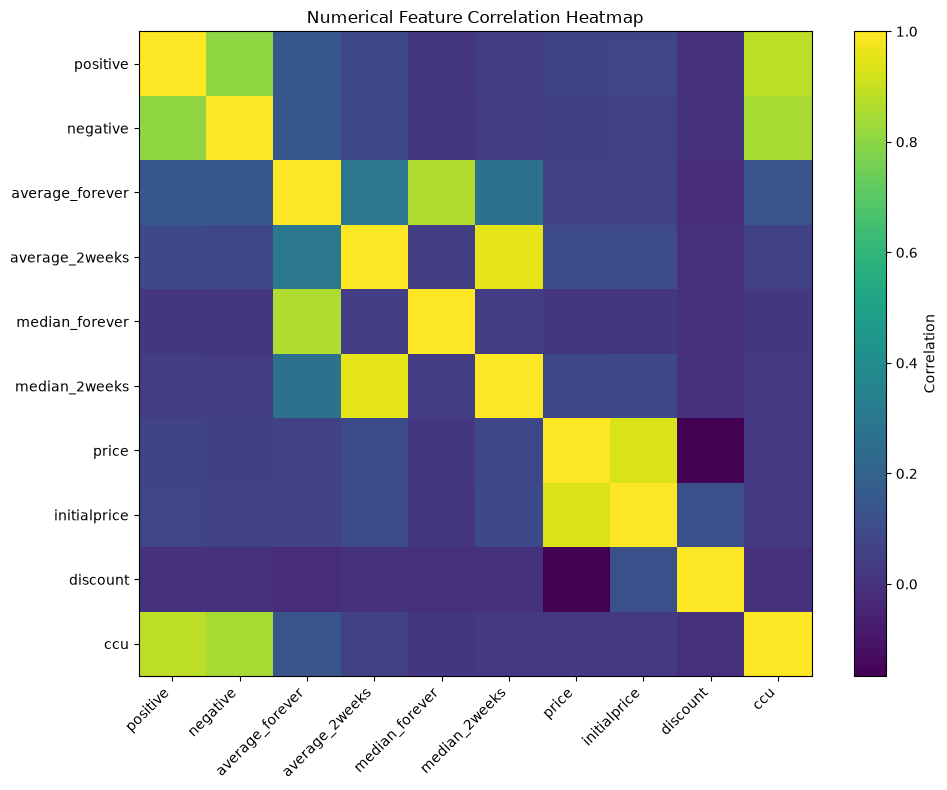

In [86]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numerical_features)),
    numerical_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numerical_features)),
    numerical_features
)

plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()

plt.show()

In [87]:
import plotly.express as px

dashboard_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Game": df["name"],
    "Anomaly Methods": df["anomaly_method_count"],
    "Z-Score": df["zscore_anomaly"],
    "Isolation Forest": df["iforest_anomaly"],
    "LOF": df["lof_anomaly"]
})

fig = px.scatter(
    dashboard_df,
    x="PC1",
    y="PC2",
    color="Anomaly Methods",
    hover_name="Game",
    hover_data=[
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],
    title="Interactive Anomaly Exploration in PCA Space"
)

fig.show()

The interactive PCA visualization allows individual games to be explored directly.

Each observation is colored according to the number of anomaly detection methods that identified it as unusual. Games detected by multiple methods can therefore be distinguished from observations identified by only one method or by none.

Hover information provides the game name and the classification result of each anomaly detection method, allowing the statistical results to be connected directly to real Steam games.